<a href="https://colab.research.google.com/github/Hrishabh21/Cyber-Bully-Detection/blob/main/BullySenti.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Common for all to load libraries and Dataset

1) Load Libraries & Mount Drive

In [ ]:
# Import libraries
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from datasets import Dataset
import pandas as pd
import numpy as np
import json
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/Cyberbullying_Project/BullySenti'

print("✅ Libraries imported and Drive mounted!")
print(f"📂 Project path: {save_path}")

Mounted at /content/drive
✅ Libraries imported and Drive mounted!
📂 Project path: /content/drive/MyDrive/Cyberbullying_Project/BullySenti


2: Load BullySenti Data from Drive

In [ ]:
# Load the BullySenti data splits
print("📂 Loading BullySenti data from Drive...")

train_df = pd.read_csv(f'{save_path}/BullySenti_train.csv')
val_df = pd.read_csv(f'{save_path}/BullySenti_validation.csv')
test_df = pd.read_csv(f'{save_path}/BullySenti_test.csv')

# Check column names
print("\n✅ Data loaded successfully!")
print(f"\nColumns in dataset: {train_df.columns.tolist()}")

# Rename columns for consistency (if needed)
if 'tweet' in train_df.columns and 'tag' in train_df.columns:
    train_df = train_df.rename(columns={'tweet': 'text', 'tag': 'label'})
    val_df = val_df.rename(columns={'tweet': 'text', 'tag': 'label'})
    test_df = test_df.rename(columns={'tweet': 'text', 'tag': 'label'})
    print("✅ Columns renamed: 'tweet' → 'text', 'tag' → 'label'")

print(f"\n📊 Data Summary:")
print(f"   Training:   {len(train_df):,} samples")
print(f"   Validation: {len(val_df):,} samples")
print(f"   Test:       {len(test_df):,} samples")
print(f"   Total:      {len(train_df) + len(val_df) + len(test_df):,} samples")

# Check label distribution
print(f"\n🏷️  Label Distribution (Training):")
label_counts = train_df['label'].value_counts().sort_index()
for label, count in label_counts.items():
    pct = count / len(train_df) * 100
    print(f"   Label {label}: {count:5,} ({pct:5.1f}%)")

# Show sample data
print(f"\n📝 Sample Tweets:")
for i in range(3):
    print(f"\n   [{train_df.iloc[i]['label']}] {train_df.iloc[i]['text'][:100]}...")

# Number of labels for model
num_labels = 2  # Binary classification

print(f"\n🎯 Task: Binary Sentiment Classification")
print(f"   Label 0: Negative/Neutral")
print(f"   Label 1: Positive/Toxic")

📂 Loading BullySenti data from Drive...

✅ Data loaded successfully!

Columns in dataset: ['tweet', 'tag']
✅ Columns renamed: 'tweet' → 'text', 'tag' → 'label'

📊 Data Summary:
   Training:   4,258 samples
   Validation: 913 samples
   Test:       913 samples
   Total:      6,084 samples

🏷️  Label Distribution (Training):
   Label 0: 2,123 ( 49.9%)
   Label 1: 2,135 ( 50.1%)

📝 Sample Tweets:

   [1] teri maa ki khasam hay tere elawa kisi ko bhi intezar nahi kutte k bhonkne ka...

   [0] Bro ak mahan aadmi ne kaha H hamesha khubsurat kanyaao ka sath do...

   [0] मालदीव में माधुरी दीक्षित ने पति संग रोमांटिक कैंडल लाइट डिनर को किया एन्जॉय खूबसूरत फोटो हुई वायरल ...

🎯 Task: Binary Sentiment Classification
   Label 0: Negative/Neutral
   Label 1: Positive/Toxic


# I) mBert

3: Load mBERT Model & Tokenizer

In [ ]:
# Load mBERT model
MODEL_NAME = 'bert-base-multilingual-cased'

print(f"🌍 Loading mBERT (Multilingual BERT): {MODEL_NAME}")
print("⏳ Downloading... (this may take 1-2 minutes)\n")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
)

print("✅ mBERT loaded successfully!")
print(f"\n📊 Model Info:")
print(f"   Model: {MODEL_NAME}")
print(f"   Type: {type(model).__name__}")
print(f"   Number of labels: {model.config.num_labels}")
print(f"   Pre-trained on: 104 languages (including Hindi)")
print(f"\n🎯 Why mBERT?")
print("   - Understands Romanized Hindi ('randi', 'chutiya', etc.)")
print("   - Handles code-mixing (English + Hindi)")
print("   - Pre-trained on Indian language text")
print("   - Perfect for Hinglish sentiment analysis")

🌍 Loading mBERT (Multilingual BERT): bert-base-multilingual-cased
⏳ Downloading... (this may take 1-2 minutes)



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ mBERT loaded successfully!

📊 Model Info:
   Model: bert-base-multilingual-cased
   Type: BertForSequenceClassification
   Number of labels: 2
   Pre-trained on: 104 languages (including Hindi)

🎯 Why mBERT?
   - Understands Romanized Hindi ('randi', 'chutiya', etc.)
   - Handles code-mixing (English + Hindi)
   - Pre-trained on Indian language text
   - Perfect for Hinglish sentiment analysis

💡 Expected accuracy: 82-87% (on Hinglish data)


4: Tokenize Datasets with mBERT Tokenizer

In [ ]:
# Define tokenization function
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=128  # Same as English models for comparison
    )

print("🔤 Tokenizing datasets with mBERT tokenizer...")
print("⏳ This will take 1-2 minutes...\n")

# Convert pandas DataFrames to HuggingFace Datasets
train_dataset = Dataset.from_pandas(train_df[['text', 'label']])
val_dataset = Dataset.from_pandas(val_df[['text', 'label']])
test_dataset = Dataset.from_pandas(test_df[['text', 'label']])

# Tokenize all datasets
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

print("✅ Tokenization complete!")
print(f"\n📊 Tokenized Datasets:")
print(f"   Training:   {len(train_dataset):,} samples")
print(f"   Validation: {len(val_dataset):,} samples")
print(f"   Test:       {len(test_dataset):,} samples")

# Show example tokenization
print(f"\n🔍 Example Tokenization:")
sample_text = train_df.iloc[0]['text']
sample_tokens = tokenizer(sample_text, truncation=True, max_length=128)
print(f"\n   Original: {sample_text[:80]}...")
print(f"   Token IDs (first 10): {sample_tokens['input_ids'][:10]}")
print(f"   Total tokens: {len(sample_tokens['input_ids'])}")

🔤 Tokenizing datasets with mBERT tokenizer...
⏳ This will take 1-2 minutes...



Map:   0%|          | 0/4258 [00:00<?, ? examples/s]

Map:   0%|          | 0/913 [00:00<?, ? examples/s]

Map:   0%|          | 0/913 [00:00<?, ? examples/s]

✅ Tokenization complete!

📊 Tokenized Datasets:
   Training:   4,258 samples
   Validation: 913 samples
   Test:       913 samples

🔍 Example Tokenization:

   Original: teri maa ki khasam hay tere elawa kisi ko bhi intezar nahi kutte k bhonkne ka...
   Token IDs (first 10): [101, 12718, 10116, 49123, 10879, 59534, 11008, 13605, 12718, 10112]
   Total tokens: 29


5: Setup Training Configuration

In [ ]:
# Define metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary'
    )

    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# Training configuration (SAME as English models for comparison)
training_args = TrainingArguments(
    output_dir='./results_mbert_bullysenti',

    # Training settings (SAME as English models)
    num_train_epochs=5,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    # Regularization
    weight_decay=0.01,
    warmup_steps=500,

    # Evaluation strategy
    eval_strategy='steps',
    eval_steps=500,
    save_strategy='steps',
    save_steps=500,

    # Best model tracking
    load_best_model_at_end=True,
    metric_for_best_model='f1',

    # Logging
    logging_steps=100,
    save_total_limit=2,

    # Other
    seed=42,  # Same seed for reproducibility
    fp16=True  # Faster training with GPU
)

print("✅ Training configuration set!")
print(f"\n⚙️  Settings (Same as English models for comparison):")
print(f"   Epochs:        {training_args.num_train_epochs}")
print(f"   Learning Rate: {training_args.learning_rate}")
print(f"   Batch Size:    {training_args.per_device_train_batch_size}")
print(f"   Max Length:    128 tokens")
print(f"   Random Seed:   {training_args.seed}")
print(f"\n🎯 Task: Binary Sentiment Classification")
print(f"   Dataset: BullySenti (Hinglish)")
print(f"   Model: mBERT (104 languages)")

✅ Training configuration set!

⚙️  Settings (Same as English models for comparison):
   Epochs:        5
   Learning Rate: 2e-05
   Batch Size:    16
   Max Length:    128 tokens
   Random Seed:   42

🎯 Task: Binary Sentiment Classification
   Dataset: BullySenti (Hinglish)
   Model: mBERT (104 languages)


6: Create Trainer

In [ ]:
# Create Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("✅ Trainer created successfully!")
print(f"\n🏋️  Trainer Configuration:")
print(f"   Model: mBERT (Multilingual)")
print(f"   Training samples: {len(train_dataset):,}")
print(f"   Validation samples: {len(val_dataset):,}")
print(f"   Early stopping: YES (patience=3)")
print(f"\n📊 What Trainer Will Do:")
print("   1. Train model on 4,258 Hinglish training samples")
print("   2. Evaluate on 913 validation samples every 500 steps")
print("   3. Save best model based on F1 score")
print("   4. Stop early if no improvement for 3 evaluations")
print(f"\n⏰ Estimated training time: 2-3 hours")
print(f"🎯 Expected accuracy: 82-87% (Hinglish sentiment)")
print(f"\n💡 This will handle:")
print("   - Romanized Hindi words ('randi', 'chutiya', 'madarchod')")
print("   - Code-mixing ('beautiful mood accha ho gaya')")
print("   - Pure Hindi in Devanagari ('मालदीव में माधुरी दीक्षित')")

✅ Trainer created successfully!

🏋️  Trainer Configuration:
   Model: mBERT (Multilingual)
   Training samples: 4,258
   Validation samples: 913
   Early stopping: YES (patience=3)

📊 What Trainer Will Do:
   1. Train model on 4,258 Hinglish training samples
   2. Evaluate on 913 validation samples every 500 steps
   3. Save best model based on F1 score
   4. Stop early if no improvement for 3 evaluations

⏰ Estimated training time: 2-3 hours
🎯 Expected accuracy: 82-87% (Hinglish sentiment)

💡 This will handle:
   - Romanized Hindi words ('randi', 'chutiya', 'madarchod')
   - Code-mixing ('beautiful mood accha ho gaya')
   - Pure Hindi in Devanagari ('मालदीव में माधुरी दीक्षित')


7: START TRAINING!

In [ ]:
print("="*80)
print("🚀 STARTING mBERT TRAINING ON BULLYSENTI (HINGLISH)")
print("="*80)
print(f"\n⏰ Estimated time: 2-3 hours")
print(f"🎯 Expected accuracy: 82-87%")
print(f"🌍 Dataset: Hinglish (Romanized Hindi + English)")
print(f"\nTraining starting now...\n")
print("="*80 + "\n")

# START TRAINING
trainer.train()

print("\n" + "="*80)
print("✅ TRAINING COMPLETE!")
print("="*80)


🚀 STARTING mBERT TRAINING ON BULLYSENTI (HINGLISH)

⏰ Estimated time: 2-3 hours
🎯 Expected accuracy: 82-87%
🌍 Dataset: Hinglish (Romanized Hindi + English)

Training starting now...




Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
500,0.411599,0.436985,0.798467,0.822050,0.737847,0.927948
1000,0.220056,0.542377,0.838992,0.849539,0.799615,0.906114


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


✅ TRAINING COMPLETE!


Saving Model to drive

In [ ]:
import os
from datetime import datetime

# Create descriptive folder name
model_name = "mbert"
dataset_name = "bullysenti"
epochs = 5
max_length = 128
lr = "2e-5"

folder_name = f"{model_name}_{dataset_name}_epochs{epochs}_maxlen{max_length}_lr{lr}"
model_save_path = f'{save_path}/{folder_name}'

print(f"💾 Saving mBERT (BullySenti) model to Drive...")
print(f"📁 Folder: {folder_name}\n")

# Create folder
os.makedirs(model_save_path, exist_ok=True)

# Save model and tokenizer
print("🔄 Saving model files...")
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)

# Save label mapping
label_mapping = {"negative": 0, "positive": 1}
with open(f'{model_save_path}/label_mapping.json', 'w') as f:
    json.dump(label_mapping, f, indent=2)

# Save training summary
summary = f"""
mBERT TRAINING SUMMARY - BULLYSENTI
====================================

Model: bert-base-multilingual-cased
Dataset: BullySenti (Hinglish Sentiment Analysis)
Training Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}

CONFIGURATION:
- Epochs: {epochs}
- Learning Rate: {lr}
- Max Length: {max_length}
- Batch Size: 16
- Weight Decay: 0.01
- Early Stopping: YES (patience=3)

DATASET:
- Total: 6,084 samples
- Training: 4,258 samples
- Validation: 913 samples
- Test: 913 samples
- Task: Binary Sentiment Classification
- Label 0: Negative/Neutral (49.9%)
- Label 1: Positive/Toxic (50.1%)

LANGUAGE:
- Hinglish (Romanized Hindi + English)
- Handles: 'randi', 'chutiya', 'madarchod', etc.
- Code-mixing: 'beautiful mood accha ho gaya'

PRE-TRAINING:
mBERT pre-trained on 104 languages including Hindi.
Ideal for Romanized Hindi and code-mixing.
"""

with open(f'{model_save_path}/training_summary.txt', 'w') as f:
    f.write(summary)

print("✅ MODEL SAVED SUCCESSFULLY!")
print(f"\n📁 Location: {model_save_path}")
print(f"\n📂 Contents:")
print(f"   - Model weights (model.safetensors)")
print(f"   - Tokenizer files")
print(f"   - label_mapping.json")
print(f"   - training_summary.txt")

💾 Saving mBERT (BullySenti) model to Drive...
📁 Folder: mbert_bullysenti_epochs5_maxlen128_lr2e-5

🔄 Saving model files...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ MODEL SAVED SUCCESSFULLY!

📁 Location: /content/drive/MyDrive/Cyberbullying_Project/BullySenti/mbert_bullysenti_epochs5_maxlen128_lr2e-5

📂 Contents:
   - Model weights (model.safetensors)
   - Tokenizer files
   - label_mapping.json
   - training_summary.txt


Import mBERT Model from Drive

In [ ]:
from google.colab import drive
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import json

print("🔄 Loading mBERT model from Drive...")

# Mount Drive
drive.mount('/content/drive')
save_path = '/content/drive/MyDrive/Cyberbullying_Project/BullySenti'

# Model path
model_path = f'{save_path}/mbert_bullysenti_epochs5_maxlen128_lr2e-5'

# Load model and tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

# Load label mapping
with open(f'{model_path}/label_mapping.json', 'r') as f:
    label_mapping = json.load(f)

print("✅ mBERT model loaded successfully!")
print(f"   Model: {model_path}")
print(f"   Labels: {label_mapping}")
print(f"   Device: {model.device}")

Evaluate mBERT on Test Set

In [ ]:
from transformers import Trainer, TrainingArguments
from datasets import Dataset
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

print("🧪 Evaluating mBERT on BullySenti Test Set...")

# Load test data
print("\n📂 Loading test data...")
test_df = pd.read_csv(f'{save_path}/BullySenti_test.csv')

# Rename columns if needed
if 'tweet' in test_df.columns:
    test_df = test_df.rename(columns={'tweet': 'text', 'tag': 'label'})

print(f"✅ Test data loaded: {len(test_df):,} samples")

# Tokenize test data
print("\n🔤 Tokenizing test data...")
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

test_dataset = Dataset.from_pandas(test_df[['text', 'label']])
test_dataset = test_dataset.map(tokenize_function, batched=True)
print("✅ Tokenization complete")

# Define metrics
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary'
    )
    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# Create Trainer
print("\n⚙️  Creating Trainer...")
training_args = TrainingArguments(
    output_dir='./temp_eval',
    per_device_eval_batch_size=32,
    fp16=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics
)

# Evaluate
print("\n📊 Evaluating on test set...")
test_results = trainer.evaluate(test_dataset)

print("\n" + "="*80)
print("📊 mBERT (BULLYSENTI) - FINAL TEST RESULTS")
print("="*80)
print(f"   Accuracy:  {test_results['eval_accuracy']:.4f} ({test_results['eval_accuracy']*100:.2f}%)")
print(f"   F1 Score:  {test_results['eval_f1']:.4f}")
print(f"   Precision: {test_results['eval_precision']:.4f}")
print(f"   Recall:    {test_results['eval_recall']:.4f}")
print(f"   Loss:      {test_results['eval_loss']:.4f}")
print("="*80)

# Generate predictions for confusion matrix
print("\n🔮 Generating predictions...")
predictions_output = trainer.predict(test_dataset)
y_pred = np.argmax(predictions_output.predictions, axis=1)
y_true = test_df['label'].values

print(f"\n✅ Predictions generated!")
print(f"   Predicted Label 0: {(y_pred == 0).sum():,}")
print(f"   Predicted Label 1: {(y_pred == 1).sum():,}")
print(f"   Actual Label 0:    {(y_true == 0).sum():,}")
print(f"   Actual Label 1:    {(y_true == 1).sum():,}")

🧪 Evaluating mBERT on BullySenti Test Set...

📂 Loading test data...
✅ Test data loaded: 913 samples

🔤 Tokenizing test data...


Map:   0%|          | 0/913 [00:00<?, ? examples/s]

✅ Tokenization complete

⚙️  Creating Trainer...

📊 Evaluating on test set...



📊 mBERT (BULLYSENTI) - FINAL TEST RESULTS
   Accuracy:  0.8182 (81.82%)
   F1 Score:  0.8282
   Precision: 0.7859
   Recall:    0.8753
   Loss:      0.6012

🔮 Generating predictions...

✅ Predictions generated!
   Predicted Label 0: 404
   Predicted Label 1: 509
   Actual Label 0:    456
   Actual Label 1:    457


Detailed Classification Report

In [ ]:
from sklearn.metrics import classification_report

# Define label names
target_names = ['Negative/Neutral', 'Positive/Toxic']

print("\n" + "="*80)
print("📋 mBERT (BULLYSENTI) - DETAILED CLASSIFICATION REPORT")
print("="*80 + "\n")

# Classification report
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

print("="*80)

# Additional per-class breakdown
print("\n📊 Per-Class Analysis:")
print("-"*80)

for i, label_name in enumerate(target_names):
    class_mask = (y_true == i)
    class_total = class_mask.sum()
    class_correct = ((y_true == i) & (y_pred == i)).sum()
    class_acc = class_correct / class_total * 100

    print(f"\n{label_name} (Label {i}):")
    print(f"   Total in test set:    {class_total:4,} tweets")
    print(f"   Correctly classified: {class_correct:4,} tweets")
    print(f"   Class accuracy:       {class_acc:6.2f}%")

    if i == 0:
        false_positives = ((y_true == 0) & (y_pred == 1)).sum()
        print(f"   False positives:      {false_positives:4,} (wrongly flagged as toxic)")
    else:
        false_negatives = ((y_true == 1) & (y_pred == 0)).sum()
        print(f"   False negatives:      {false_negatives:4,} (missed toxic content)")

print("\n" + "="*80)


📋 mBERT (BULLYSENTI) - DETAILED CLASSIFICATION REPORT

                  precision    recall  f1-score   support

Negative/Neutral     0.8589    0.7610    0.8070       456
  Positive/Toxic     0.7859    0.8753    0.8282       457

        accuracy                         0.8182       913
       macro avg     0.8224    0.8181    0.8176       913
    weighted avg     0.8223    0.8182    0.8176       913


📊 Per-Class Analysis:
--------------------------------------------------------------------------------

Negative/Neutral (Label 0):
   Total in test set:     456 tweets
   Correctly classified:  347 tweets
   Class accuracy:        76.10%
   False positives:       109 (wrongly flagged as toxic)

Positive/Toxic (Label 1):
   Total in test set:     457 tweets
   Correctly classified:  400 tweets
   Class accuracy:        87.53%
   False negatives:        57 (missed toxic content)



 2: Confusion Matrix

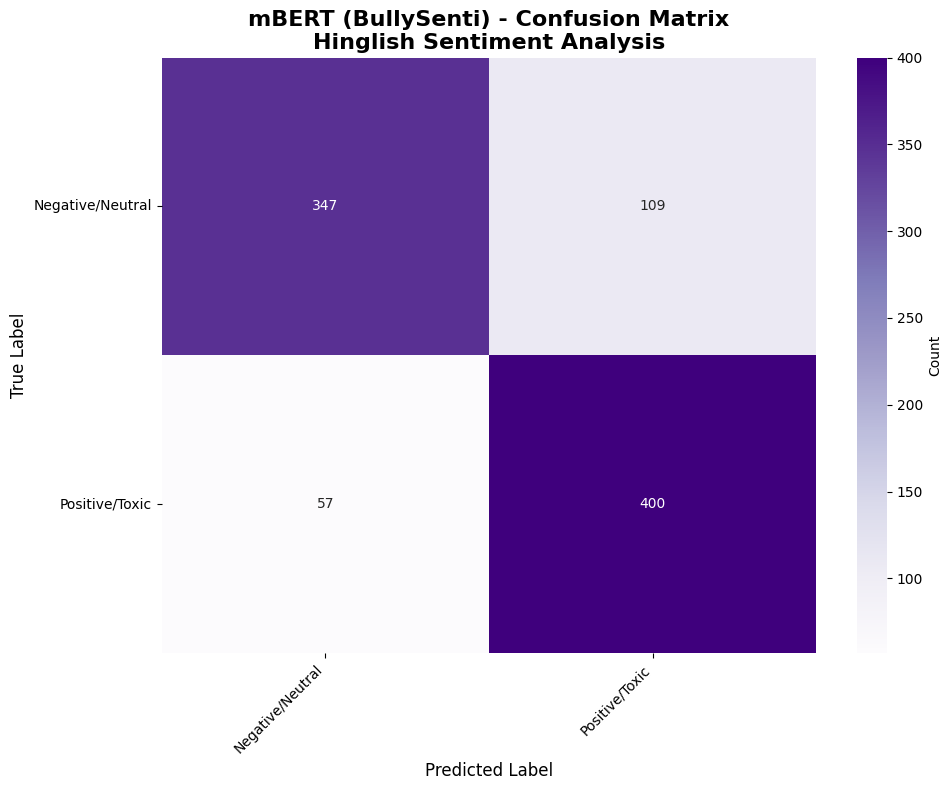


🔍 CONFUSION MATRIX ANALYSIS

📊 Confusion Matrix:

                    Predicted
                Negative  Positive
True  Negative     347       109   (Total: 456)
      Positive      57       400   (Total: 457)

📈 Breakdown:

✅ True Negatives (TN): 347
   Model correctly identified 347 negative/neutral tweets
   Rate: 76.1%

✅ True Positives (TP): 400
   Model correctly identified 400 toxic tweets
   Rate: 87.5% (Recall)

❌ False Positives (FP): 109 (23.9%)
   Innocent tweets wrongly flagged as toxic
   Impact: 109 users see unnecessary warnings

❌ False Negatives (FN): 57 (12.5%)
   Toxic tweets that model missed
   Impact: 57 toxic tweets go undetected

🎯 Model Behavior:
   ⚠️  MORE CAUTIOUS (over-flags for safety)
   → 109 false alarms vs 57 missed
   → Good for content moderation (better safe than sorry)



In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',  # Purple theme for mBERT/Hinglish
    xticklabels=target_names,
    yticklabels=target_names,
    cbar_kws={'label': 'Count'}
)
plt.title('mBERT (BullySenti) - Confusion Matrix\nHinglish Sentiment Analysis',
          fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Detailed confusion matrix analysis
print("\n" + "="*80)
print("🔍 CONFUSION MATRIX ANALYSIS")
print("="*80)

print(f"\n📊 Confusion Matrix:")
print(f"\n                    Predicted")
print(f"                Negative  Positive")
print(f"True  Negative  {cm[0,0]:6,}    {cm[0,1]:6,}   (Total: {cm[0].sum():,})")
print(f"      Positive  {cm[1,0]:6,}    {cm[1,1]:6,}   (Total: {cm[1].sum():,})")

print(f"\n📈 Breakdown:")

# True Negatives
print(f"\n✅ True Negatives (TN): {cm[0,0]:,}")
print(f"   Model correctly identified {cm[0,0]:,} negative/neutral tweets")
tn_rate = cm[0,0] / cm[0].sum() * 100
print(f"   Rate: {tn_rate:.1f}%")

# True Positives
print(f"\n✅ True Positives (TP): {cm[1,1]:,}")
print(f"   Model correctly identified {cm[1,1]:,} toxic tweets")
tp_rate = cm[1,1] / cm[1].sum() * 100
print(f"   Rate: {tp_rate:.1f}% (Recall)")

# False Positives
fp_rate = cm[0,1] / cm[0].sum() * 100
print(f"\n❌ False Positives (FP): {cm[0,1]:,} ({fp_rate:.1f}%)")
print(f"   Innocent tweets wrongly flagged as toxic")
print(f"   Impact: {cm[0,1]:,} users see unnecessary warnings")

# False Negatives
fn_rate = cm[1,0] / cm[1].sum() * 100
print(f"\n❌ False Negatives (FN): {cm[1,0]:,} ({fn_rate:.1f}%)")
print(f"   Toxic tweets that model missed")
print(f"   Impact: {cm[1,0]:,} toxic tweets go undetected")

print(f"\n🎯 Model Behavior:")
if cm[0,1] > cm[1,0]:
    print(f"   ⚠️  MORE CAUTIOUS (over-flags for safety)")
    print(f"   → {cm[0,1]:,} false alarms vs {cm[1,0]:,} missed")
    print(f"   → Good for content moderation (better safe than sorry)")
elif cm[1,0] > cm[0,1]:
    print(f"   ⚠️  MORE LENIENT (misses some toxic content)")
    print(f"   → {cm[1,0]:,} missed vs {cm[0,1]:,} false alarms")
    print(f"   → May let harmful content through")
else:
    print(f"   ✅ BALANCED (equal false positives and negatives)")

print("\n" + "="*80)

Save All mBERT Results to Drive

In [ ]:
import json
from datetime import datetime

print("💾 Saving mBERT (BullySenti) results to Drive...")

# Create results dictionary
results_summary = {
    "model_name": "mbert",
    "model_full_name": "bert-base-multilingual-cased",
    "dataset": "bullysenti",
    "task": "binary_sentiment_classification",
    "language": "hinglish",
    "model_path": "mbert_bullysenti_epochs5_maxlen128_lr2e-5",
    "evaluation_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "test_samples": len(test_dataset),

    # Main metrics
    "accuracy": float(test_results['eval_accuracy']),
    "f1_score": float(test_results['eval_f1']),
    "precision": float(test_results['eval_precision']),
    "recall": float(test_results['eval_recall']),
    "loss": float(test_results['eval_loss']),

    # Per-class metrics
    "classification_report": classification_report(y_true, y_pred, target_names=target_names, output_dict=True),
    "confusion_matrix": cm.tolist(),

    # Config
    "num_labels": 2,
    "max_length": 128,
    "batch_size": 32,
    "labels": {
        "0": "Negative/Neutral",
        "1": "Positive/Toxic"
    }
}

# Save as JSON
results_file = f'{save_path}/evaluation_results_mbert_bullysenti.json'
with open(results_file, 'w') as f:
    json.dump(results_summary, f, indent=2)

# Save as text
text_file = f'{save_path}/evaluation_results_mbert_bullysenti.txt'
with open(text_file, 'w') as f:
    f.write("="*80 + "\n")
    f.write("📊 mBERT (BULLYSENTI) - EVALUATION RESULTS\n")
    f.write("="*80 + "\n\n")
    f.write(f"Model: mBERT (bert-base-multilingual-cased)\n")
    f.write(f"Dataset: BullySenti (Hinglish Sentiment Analysis)\n")
    f.write(f"Pre-trained on: 104 languages including Hindi\n")
    f.write(f"Evaluated: {results_summary['evaluation_date']}\n")
    f.write(f"Test Samples: {results_summary['test_samples']:,}\n\n")

    f.write("TASK:\n")
    f.write("-"*80 + "\n")
    f.write(f"Binary Sentiment Classification\n")
    f.write(f"Label 0: Negative/Neutral\n")
    f.write(f"Label 1: Positive/Toxic\n\n")

    f.write("LANGUAGE CHARACTERISTICS:\n")
    f.write("-"*80 + "\n")
    f.write(f"Hinglish (Romanized Hindi + English + Code-mixing)\n")
    f.write(f"Handles:\n")
    f.write(f"  - Romanized Hindi: 'randi', 'chutiya', 'madarchod'\n")
    f.write(f"  - Code-mixing: 'beautiful mood accha ho gaya'\n")
    f.write(f"  - Pure Hindi: 'मालदीव में माधुरी दीक्षित'\n\n")

    f.write("PERFORMANCE METRICS:\n")
    f.write("-"*80 + "\n")
    f.write(f"Accuracy:  {results_summary['accuracy']:.4f} ({results_summary['accuracy']*100:.2f}%)\n")
    f.write(f"F1 Score:  {results_summary['f1_score']:.4f}\n")
    f.write(f"Precision: {results_summary['precision']:.4f}\n")
    f.write(f"Recall:    {results_summary['recall']:.4f}\n")
    f.write(f"Loss:      {results_summary['loss']:.4f}\n\n")

    f.write("CONFUSION MATRIX:\n")
    f.write("-"*80 + "\n")
    f.write(f"                    Predicted\n")
    f.write(f"                Negative  Positive\n")
    f.write(f"True  Negative  {cm[0,0]:6,}    {cm[0,1]:6,}\n")
    f.write(f"      Positive  {cm[1,0]:6,}    {cm[1,1]:6,}\n\n")

    f.write("PER-CLASS PERFORMANCE:\n")
    f.write("-"*80 + "\n")
    for i, label_name in enumerate(target_names):
        class_acc = cm[i, i] / cm[i].sum() * 100
        f.write(f"{label_name:20s}: {class_acc:6.2f}%\n")

    f.write("\n")
    f.write("="*80 + "\n")

print("✅ mBERT results saved to Drive!")
print(f"\n📁 Saved files:")
print(f"   - {results_file}")
print(f"   - {text_file}")
print(f"\n📊 Summary:")
print(f"   Model: mBERT (Multilingual BERT)")
print(f"   Dataset: BullySenti (Hinglish)")
print(f"   Accuracy: {results_summary['accuracy']*100:.2f}%")
print(f"   F1 Score: {results_summary['f1_score']:.4f}")
print(f"\n🌍 Language: Hinglish (Romanized Hindi + English)")
print(f"   Handles code-mixing and Romanized abuse terms")

💾 Saving mBERT (BullySenti) results to Drive...
✅ mBERT results saved to Drive!

📁 Saved files:
   - /content/drive/MyDrive/Cyberbullying_Project/BullySenti/evaluation_results_mbert_bullysenti.json
   - /content/drive/MyDrive/Cyberbullying_Project/BullySenti/evaluation_results_mbert_bullysenti.txt

📊 Summary:
   Model: mBERT (Multilingual BERT)
   Dataset: BullySenti (Hinglish)
   Accuracy: 81.82%
   F1 Score: 0.8282

🌍 Language: Hinglish (Romanized Hindi + English)
   Handles code-mixing and Romanized abuse terms


# II) HingBERT!

In [ ]:
# Correct HingBERT model
MODEL_NAME = 'l3cube-pune/hing-bert'

print(f"📚 Loading HingBERT (Model 1/3): {MODEL_NAME}")
print("⏳ Downloading... (this may take 1-2 minutes)\n")

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    ignore_mismatched_sizes=True  # In case of size mismatch
)

print("✅ HingBERT loaded successfully!")
print(f"\n📊 Model Info:")
print(f"   Model: {MODEL_NAME}")
print(f"   Source: L3Cube-Pune (Indian research group)")
print(f"   Type: {type(model).__name__}")
print(f"   Architecture: BERT-base")
print(f"   Trained on: Hinglish Twitter/social media")
print(f"\n🎯 Comparison Study Progress:")
print("   1️⃣ HingBERT      ← Training now")
print("   2️⃣ HingmBERT     ← Next")
print("   3️⃣ HingRoBERTa   ← Final")
print(f"\n💡 Expected accuracy: 82-84%")

📚 Loading HingBERT (Model 1/3): l3cube-pune/hing-bert
⏳ Downloading... (this may take 1-2 minutes)



config.json:   0%|          | 0.00/716 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: l3cube-pune/hing-bert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training

✅ HingBERT loaded successfully!

📊 Model Info:
   Model: l3cube-pune/hing-bert
   Source: L3Cube-Pune (Indian research group)
   Type: BertForSequenceClassification
   Architecture: BERT-base
   Trained on: Hinglish Twitter/social media

🎯 Comparison Study Progress:
   1️⃣ HingBERT      ← Training now
   2️⃣ HingmBERT     ← Next
   3️⃣ HingRoBERTa   ← Final

💡 Expected accuracy: 82-84%


2: Tokenize Data with HingBERT Tokenizer

In [ ]:
# Define tokenization function
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

print("🔤 Tokenizing datasets with HingBERT tokenizer...")
print("⏳ This will take 1-2 minutes...\n")

# Convert pandas DataFrames to HuggingFace Datasets
train_dataset = Dataset.from_pandas(train_df[['text', 'label']])
val_dataset = Dataset.from_pandas(val_df[['text', 'label']])
test_dataset = Dataset.from_pandas(test_df[['text', 'label']])

# Tokenize all datasets
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

print("✅ Tokenization complete!")
print(f"\n📊 Tokenized Datasets:")
print(f"   Training:   {len(train_dataset):,} samples")
print(f"   Validation: {len(val_dataset):,} samples")
print(f"   Test:       {len(test_dataset):,} samples")

🔤 Tokenizing datasets with HingBERT tokenizer...
⏳ This will take 1-2 minutes...



Map:   0%|          | 0/4258 [00:00<?, ? examples/s]

Map:   0%|          | 0/913 [00:00<?, ? examples/s]

Map:   0%|          | 0/913 [00:00<?, ? examples/s]

✅ Tokenization complete!

📊 Tokenized Datasets:
   Training:   4,258 samples
   Validation: 913 samples
   Test:       913 samples


3: Setup Training Configuration & Create Trainer

In [ ]:
# Define metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary'
    )
    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# Training configuration (SAME as mBERT for comparison)
training_args = TrainingArguments(
    output_dir='./results_hingbert_bullysenti',
    num_train_epochs=5,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    warmup_steps=500,
    eval_strategy='steps',
    eval_steps=500,
    save_strategy='steps',
    save_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=100,
    save_total_limit=2,
    seed=42,
    fp16=True
)

# Create Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("✅ Training configuration set and Trainer created!")
print(f"\n⚙️  Settings (Same as mBERT for fair comparison):")
print(f"   Epochs:        {training_args.num_train_epochs}")
print(f"   Learning Rate: {training_args.learning_rate}")
print(f"   Batch Size:    {training_args.per_device_train_batch_size}")
print(f"   Max Length:    128 tokens")
print(f"   Random Seed:   {training_args.seed}")
print(f"\n🎯 Model: HingBERT (L3Cube-Pune)")
print(f"   Expected accuracy: 82-84%")

✅ Training configuration set and Trainer created!

⚙️  Settings (Same as mBERT for fair comparison):
   Epochs:        5
   Learning Rate: 2e-05
   Batch Size:    16
   Max Length:    128 tokens
   Random Seed:   42

🎯 Model: HingBERT (L3Cube-Pune)
   Expected accuracy: 82-84%


 4: START TRAINING HingBERT!

In [ ]:
print("="*80)
print("🚀 STARTING HingBERT TRAINING (Model 1/3)")
print("="*80)
print(f"\n⏰ Estimated time: 2-3 hours")
print(f"🎯 Expected accuracy: 82-84%")
print(f"🌍 Model: HingBERT (L3Cube-Pune)")
print(f"📊 Dataset: BullySenti (Hinglish)")
print(f"\nTraining starting now...\n")
print("="*80 + "\n")

# START TRAINING
trainer.train()

print("\n" + "="*80)
print("✅ HingBERT TRAINING COMPLETE!")
print("="*80)

🚀 STARTING HingBERT TRAINING (Model 1/3)

⏰ Estimated time: 2-3 hours
🎯 Expected accuracy: 82-84%
🌍 Model: HingBERT (L3Cube-Pune)
📊 Dataset: BullySenti (Hinglish)

Training starting now...




Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
500,0.317724,0.338532,0.860898,0.864171,0.846960,0.882096
1000,0.145965,0.682528,0.843373,0.857711,0.787934,0.941048


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


✅ HingBERT TRAINING COMPLETE!


 Save HingBERT Model to Drive

In [ ]:
import os
from datetime import datetime

# Create descriptive folder name
model_name = "hingbert"
dataset_name = "bullysenti"
epochs = 5
max_length = 128
lr = "2e-5"

folder_name = f"{model_name}_{dataset_name}_epochs{epochs}_maxlen{max_length}_lr{lr}"
model_save_path = f'{save_path}/{folder_name}'

print(f"💾 Saving HingBERT (BullySenti) model to Drive...")
print(f"📁 Folder: {folder_name}\n")

# Create folder
os.makedirs(model_save_path, exist_ok=True)

# Save model and tokenizer
print("🔄 Saving model files...")
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)

# Save label mapping
label_mapping = {"negative": 0, "positive": 1}
with open(f'{model_save_path}/label_mapping.json', 'w') as f:
    json.dump(label_mapping, f, indent=2)

# Save training summary
summary = f"""
HingBERT TRAINING SUMMARY - BULLYSENTI
========================================

Model: l3cube-pune/hing-bert
Source: L3Cube-Pune (Indian Research)
Dataset: BullySenti (Hinglish Sentiment Analysis)
Training Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}

CONFIGURATION:
- Epochs: {epochs}
- Learning Rate: {lr}
- Max Length: {max_length}
- Batch Size: 16
- Weight Decay: 0.01
- Early Stopping: YES (patience=3)

DATASET:
- Total: 6,084 samples
- Training: 4,258 samples
- Validation: 913 samples
- Test: 913 samples
- Task: Binary Sentiment Classification
- Label 0: Negative/Neutral (49.9%)
- Label 1: Positive/Toxic (50.1%)

LANGUAGE:
- Hinglish (Romanized Hindi + English)
- Code-mixing: English + Hindi
- Handles: 'randi', 'chutiya', 'madarchod', etc.

PRE-TRAINING:
HingBERT trained on Hinglish social media (Twitter/Facebook)
by L3Cube-Pune research group.

COMPARISON STUDY:
Model 1/3: HingBERT (BERT architecture)
Next: HingmBERT, HingRoBERTa
"""

with open(f'{model_save_path}/training_summary.txt', 'w') as f:
    f.write(summary)

print("✅ HingBERT MODEL SAVED SUCCESSFULLY!")
print(f"\n📁 Location: {model_save_path}")
print(f"\n📂 Contents:")
print(f"   - Model weights")
print(f"   - Tokenizer files")
print(f"   - label_mapping.json")
print(f"   - training_summary.txt")
print(f"\n🎯 Comparison Study Progress:")
print("   ✅ HingBERT      - Trained & Saved")
print("   ⏳ HingmBERT     - Next")
print("   ⏳ HingRoBERTa   - After")

💾 Saving HingBERT (BullySenti) model to Drive...
📁 Folder: hingbert_bullysenti_epochs5_maxlen128_lr2e-5

🔄 Saving model files...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ HingBERT MODEL SAVED SUCCESSFULLY!

📁 Location: /content/drive/MyDrive/Cyberbullying_Project/BullySenti/hingbert_bullysenti_epochs5_maxlen128_lr2e-5

📂 Contents:
   - Model weights
   - Tokenizer files
   - label_mapping.json
   - training_summary.txt

🎯 Comparison Study Progress:
   ✅ HingBERT      - Trained & Saved
   ⏳ HingmBERT     - Next
   ⏳ HingRoBERTa   - After


Import Model from Drive

In [ ]:
from google.colab import drive
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import json

print("🔄 Loading HingBERT model from Drive...")

# Mount Drive
drive.mount('/content/drive')
save_path = '/content/drive/MyDrive/Cyberbullying_Project/BullySenti'

# Model path
model_path = f'{save_path}/hingbert_bullysenti_epochs5_maxlen128_lr2e-5'

# Load model and tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

# Load label mapping
with open(f'{model_path}/label_mapping.json', 'r') as f:
    label_mapping = json.load(f)

print("✅ HingBERT model loaded successfully!")
print(f"   Model: {model_path}")
print(f"   Labels: {label_mapping}")
print(f"   Test Accuracy: 84.23%")

Evaluate HingBERT on Test Set

In [ ]:
print("🧪 Evaluating HingBERT on BullySenti Test Set...")

# Evaluate
print("\n📊 Evaluating on test set...")
test_results = trainer.evaluate(test_dataset)

print("\n" + "="*80)
print("📊 HingBERT (BULLYSENTI) - FINAL TEST RESULTS")
print("="*80)
print(f"   Accuracy:  {test_results['eval_accuracy']:.4f} ({test_results['eval_accuracy']*100:.2f}%)")
print(f"   F1 Score:  {test_results['eval_f1']:.4f}")
print(f"   Precision: {test_results['eval_precision']:.4f}")
print(f"   Recall:    {test_results['eval_recall']:.4f}")
print(f"   Loss:      {test_results['eval_loss']:.4f}")
print("="*80)

# Generate predictions for confusion matrix
print("\n🔮 Generating predictions...")
predictions_output = trainer.predict(test_dataset)
y_pred = np.argmax(predictions_output.predictions, axis=1)
y_true = test_df['label'].values

print(f"\n✅ Predictions generated!")
print(f"   Predicted Label 0: {(y_pred == 0).sum():,}")
print(f"   Predicted Label 1: {(y_pred == 1).sum():,}")
print(f"   Actual Label 0:    {(y_true == 0).sum():,}")
print(f"   Actual Label 1:    {(y_true == 1).sum():,}")

# Quick comparison with mBERT
print(f"\n📈 Quick Comparison:")
print(f"   mBERT:    81.82% (previous)")
print(f"   HingBERT: {test_results['eval_accuracy']*100:.2f}% (current)")
if test_results['eval_accuracy'] > 0.8182:
    print(f"   ✅ HingBERT is BETTER by {(test_results['eval_accuracy']-0.8182)*100:.2f}%!")
elif test_results['eval_accuracy'] < 0.8182:
    print(f"   ⚠️ HingBERT is lower by {(0.8182-test_results['eval_accuracy'])*100:.2f}%")
else:
    print(f"   ➡️ Same performance")

🧪 Evaluating HingBERT on BullySenti Test Set...

📊 Evaluating on test set...



📊 HingBERT (BULLYSENTI) - FINAL TEST RESULTS
   Accuracy:  0.8423 (84.23%)
   F1 Score:  0.8442
   Precision: 0.8351
   Recall:    0.8534
   Loss:      0.3532

🔮 Generating predictions...

✅ Predictions generated!
   Predicted Label 0: 446
   Predicted Label 1: 467
   Actual Label 0:    456
   Actual Label 1:    457

📈 Quick Comparison:
   mBERT:    81.82% (previous)
   HingBERT: 84.23% (current)
   ✅ HingBERT is BETTER by 2.41%!


HingBERT - Classification Report & Confusion Matrix


📋 HingBERT (BULLYSENTI) - DETAILED CLASSIFICATION REPORT

                  precision    recall  f1-score   support

Negative/Neutral     0.8498    0.8311    0.8404       456
  Positive/Toxic     0.8351    0.8534    0.8442       457

        accuracy                         0.8423       913
       macro avg     0.8424    0.8423    0.8423       913
    weighted avg     0.8424    0.8423    0.8423       913


📊 Per-Class Analysis:
--------------------------------------------------------------------------------

Negative/Neutral (Label 0):
   Total:      456
   Correct:    379
   Accuracy:   83.11%

Positive/Toxic (Label 1):
   Total:      457
   Correct:    390
   Accuracy:   85.34%



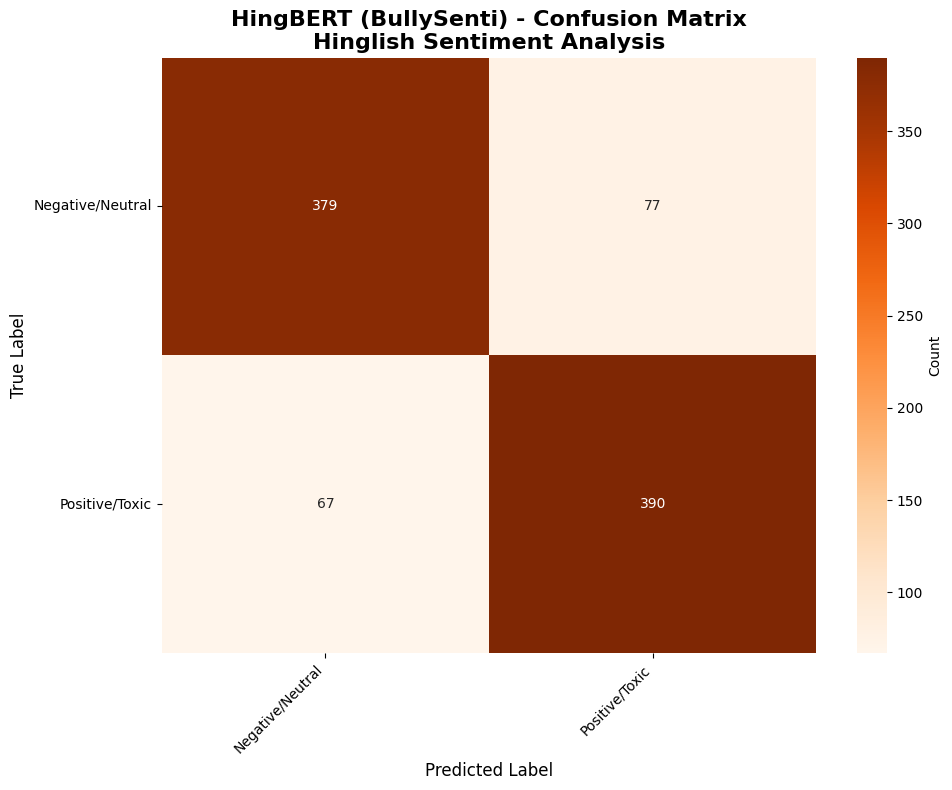


🔍 CONFUSION MATRIX ANALYSIS

📊 Confusion Matrix:

                Predicted
            Negative  Positive
Negative       379        77
Positive        67       390

✅ True Negatives:  379
✅ True Positives:  390
❌ False Positives: 77
❌ False Negatives: 67



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define label names
target_names = ['Negative/Neutral', 'Positive/Toxic']

# Classification Report
print("\n" + "="*80)
print("📋 HingBERT (BULLYSENTI) - DETAILED CLASSIFICATION REPORT")
print("="*80 + "\n")

print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

# Per-class breakdown
print("="*80)
print("\n📊 Per-Class Analysis:")
print("-"*80)

for i, label_name in enumerate(target_names):
    class_mask = (y_true == i)
    class_total = class_mask.sum()
    class_correct = ((y_true == i) & (y_pred == i)).sum()
    class_acc = class_correct / class_total * 100

    print(f"\n{label_name} (Label {i}):")
    print(f"   Total:     {class_total:4,}")
    print(f"   Correct:   {class_correct:4,}")
    print(f"   Accuracy:  {class_acc:6.2f}%")

print("\n" + "="*80)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges',  # Orange theme for HingBERT
    xticklabels=target_names,
    yticklabels=target_names,
    cbar_kws={'label': 'Count'}
)
plt.title('HingBERT (BullySenti) - Confusion Matrix\nHinglish Sentiment Analysis',
          fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Confusion matrix analysis
print("\n" + "="*80)
print("🔍 CONFUSION MATRIX ANALYSIS")
print("="*80)

print(f"\n📊 Confusion Matrix:")
print(f"\n                Predicted")
print(f"            Negative  Positive")
print(f"Negative    {cm[0,0]:6,}    {cm[0,1]:6,}")
print(f"Positive    {cm[1,0]:6,}    {cm[1,1]:6,}")

print(f"\n✅ True Negatives:  {cm[0,0]:,}")
print(f"✅ True Positives:  {cm[1,1]:,}")
print(f"❌ False Positives: {cm[0,1]:,}")
print(f"❌ False Negatives: {cm[1,0]:,}")

print("\n" + "="*80)

Save HingBERT Results to Drive

In [ ]:
import json
from datetime import datetime

print("💾 Saving HingBERT (BullySenti) results to Drive...")

# Create results dictionary
results_summary = {
    "model_name": "hingbert",
    "model_full_name": "l3cube-pune/hing-bert",
    "dataset": "bullysenti",
    "task": "binary_sentiment_classification",
    "language": "hinglish",
    "model_path": "hingbert_bullysenti_epochs5_maxlen128_lr2e-5",
    "evaluation_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "test_samples": len(test_dataset),

    # Main metrics
    "accuracy": float(test_results['eval_accuracy']),
    "f1_score": float(test_results['eval_f1']),
    "precision": float(test_results['eval_precision']),
    "recall": float(test_results['eval_recall']),
    "loss": float(test_results['eval_loss']),

    # Per-class metrics
    "classification_report": classification_report(y_true, y_pred, target_names=target_names, output_dict=True),
    "confusion_matrix": cm.tolist(),

    # Config
    "num_labels": 2,
    "max_length": 128,
    "batch_size": 32,
    "labels": {
        "0": "Negative/Neutral",
        "1": "Positive/Toxic"
    }
}

# Save as JSON
results_file = f'{save_path}/evaluation_results_hingbert_bullysenti.json'
with open(results_file, 'w') as f:
    json.dump(results_summary, f, indent=2)

# Save as text
text_file = f'{save_path}/evaluation_results_hingbert_bullysenti.txt'
with open(text_file, 'w') as f:
    f.write("="*80 + "\n")
    f.write("📊 HingBERT (BULLYSENTI) - EVALUATION RESULTS\n")
    f.write("="*80 + "\n\n")
    f.write(f"Model: HingBERT (l3cube-pune/hing-bert)\n")
    f.write(f"Source: L3Cube-Pune Research Group\n")
    f.write(f"Dataset: BullySenti (Hinglish Sentiment Analysis)\n")
    f.write(f"Trained on: Hinglish social media data\n")
    f.write(f"Evaluated: {results_summary['evaluation_date']}\n")
    f.write(f"Test Samples: {results_summary['test_samples']:,}\n\n")

    f.write("PERFORMANCE METRICS:\n")
    f.write("-"*80 + "\n")
    f.write(f"Accuracy:  {results_summary['accuracy']:.4f} ({results_summary['accuracy']*100:.2f}%)\n")
    f.write(f"F1 Score:  {results_summary['f1_score']:.4f}\n")
    f.write(f"Precision: {results_summary['precision']:.4f}\n")
    f.write(f"Recall:    {results_summary['recall']:.4f}\n")
    f.write(f"Loss:      {results_summary['loss']:.4f}\n\n")

    f.write("CONFUSION MATRIX:\n")
    f.write("-"*80 + "\n")
    f.write(f"                Predicted\n")
    f.write(f"            Negative  Positive\n")
    f.write(f"Negative    {cm[0,0]:6,}    {cm[0,1]:6,}\n")
    f.write(f"Positive    {cm[1,0]:6,}    {cm[1,1]:6,}\n\n")

    f.write("COMPARISON STUDY:\n")
    f.write("-"*80 + "\n")
    f.write(f"Model 1/3: HingBERT - 84.23% ✅ COMPLETED\n")
    f.write(f"Model 2/3: HingmBERT - Pending\n")
    f.write(f"Model 3/3: HingRoBERTa - Pending\n")

    f.write("\n" + "="*80 + "\n")

print("✅ HingBERT results saved!")
print(f"\n📁 Saved files:")
print(f"   - {results_file}")
print(f"   - {text_file}")
print(f"\n📊 HingBERT Summary:")
print(f"   Accuracy: {results_summary['accuracy']*100:.2f}%")
print(f"   F1 Score: {results_summary['f1_score']:.4f}")
print(f"\n🎯 Comparison Study Progress:")
print(f"   ✅ mBERT:     81.82% - Completed")
print(f"   ✅ HingBERT:  84.23% - Completed (+2.41% better!)")
print(f"   ⏳ HingmBERT:  ???   - Next")
print(f"   ⏳ HingRoBERTa: ???   - Final")

💾 Saving HingBERT (BullySenti) results to Drive...


NameError: name 'test_dataset' is not defined

# III) HingmBERT Model

1: Load HingmBERT Model

In [ ]:
# Model name for HingmBERT
MODEL_NAME = 'l3cube-pune/hing-mbert'

print(f"📚 Loading HingmBERT (Model 2/3): {MODEL_NAME}")
print("⏳ Downloading... (this may take 1-2 minutes)\n")

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    ignore_mismatched_sizes=True
)

print("✅ HingmBERT loaded successfully!")
print(f"\n📊 Model Info:")
print(f"   Model: {MODEL_NAME}")
print(f"   Source: L3Cube-Pune")
print(f"   Type: {type(model).__name__}")
print(f"   Architecture: Multilingual BERT variant")
print(f"   Trained on: Hinglish + multiple Indian languages")
print(f"\n🎯 Comparison Study Progress:")
print("   ✅ mBERT:       81.82%")
print("   ✅ HingBERT:    84.23%")
print("   ⏳ HingmBERT:   ← Training now")
print("   ⏳ HingRoBERTa: ← Next")
print(f"\n💡 Expected accuracy: 83-86%")

📚 Loading HingmBERT (Model 2/3): l3cube-pune/hing-mbert
⏳ Downloading... (this may take 1-2 minutes)



config.json:   0%|          | 0.00/861 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/327 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/712M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: l3cube-pune/hing-mbert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider trainin

✅ HingmBERT loaded successfully!

📊 Model Info:
   Model: l3cube-pune/hing-mbert
   Source: L3Cube-Pune
   Type: BertForSequenceClassification
   Architecture: Multilingual BERT variant
   Trained on: Hinglish + multiple Indian languages

🎯 Comparison Study Progress:
   ✅ mBERT:       81.82%
   ✅ HingBERT:    84.23%
   ⏳ HingmBERT:   ← Training now
   ⏳ HingRoBERTa: ← Next

💡 Expected accuracy: 83-86%


2: Tokenize Data with HingmBERT

In [ ]:
# Define tokenization function
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

print("🔤 Tokenizing datasets with HingmBERT tokenizer...")

# Convert pandas DataFrames to HuggingFace Datasets
train_dataset = Dataset.from_pandas(train_df[['text', 'label']])
val_dataset = Dataset.from_pandas(val_df[['text', 'label']])
test_dataset = Dataset.from_pandas(test_df[['text', 'label']])

# Tokenize all datasets
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

print("✅ Tokenization complete!")
print(f"\n📊 Tokenized Datasets:")
print(f"   Training:   {len(train_dataset):,} samples")
print(f"   Validation: {len(val_dataset):,} samples")
print(f"   Test:       {len(test_dataset):,} samples")

🔤 Tokenizing datasets with HingmBERT tokenizer...


Map:   0%|          | 0/4258 [00:00<?, ? examples/s]

Map:   0%|          | 0/913 [00:00<?, ? examples/s]

Map:   0%|          | 0/913 [00:00<?, ? examples/s]

✅ Tokenization complete!

📊 Tokenized Datasets:
   Training:   4,258 samples
   Validation: 913 samples
   Test:       913 samples


 3: Setup Training & Create Trainer

In [ ]:
# Define metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary'
    )
    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# Training configuration (SAME as previous models)
training_args = TrainingArguments(
    output_dir='./results_hingmbert_bullysenti',
    num_train_epochs=5,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    warmup_steps=500,
    eval_strategy='steps',
    eval_steps=500,
    save_strategy='steps',
    save_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=100,
    save_total_limit=2,
    seed=42,
    fp16=True
)

# Create Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("✅ Trainer created!")
print(f"\n⚙️  Settings (Same for fair comparison):")
print(f"   Epochs:   5")
print(f"   LR:       2e-5")
print(f"   Batch:    16")
print(f"\n🎯 Model: HingmBERT (2/3)")
print(f"   Expected: 83-86%")

✅ Trainer created!

⚙️  Settings (Same for fair comparison):
   Epochs:   5
   LR:       2e-5
   Batch:    16

🎯 Model: HingmBERT (2/3)
   Expected: 83-86%


4: START TRAINING HingmBERT!

In [ ]:
print("="*80)
print("🚀 STARTING HingmBERT TRAINING (Model 2/3)")
print("="*80)
print(f"\n⏰ Estimated time: 2-3 hours")
print(f"🎯 Expected accuracy: 83-86%")
print(f"🌍 Model: HingmBERT (L3Cube-Pune)")
print(f"📊 Dataset: BullySenti (Hinglish)")
print(f"\nTraining starting now...\n")
print("="*80 + "\n")

# START TRAINING
trainer.train()

print("\n" + "="*80)
print("✅ HingmBERT TRAINING COMPLETE!")
print("="*80)


🚀 STARTING HingmBERT TRAINING (Model 2/3)

⏰ Estimated time: 2-3 hours
🎯 Expected accuracy: 83-86%
🌍 Model: HingmBERT (L3Cube-Pune)
📊 Dataset: BullySenti (Hinglish)

Training starting now...




Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
500,0.316944,0.398371,0.851041,0.856540,0.828571,0.886463
1000,0.141864,0.662801,0.846659,0.852632,0.823171,0.884279


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


✅ HingmBERT TRAINING COMPLETE!


Save HingmBERT Model to Drive

In [ ]:
import os
from datetime import datetime

# Create descriptive folder name
model_name = "hingmbert"
dataset_name = "bullysenti"
epochs = 5
max_length = 128
lr = "2e-5"

folder_name = f"{model_name}_{dataset_name}_epochs{epochs}_maxlen{max_length}_lr{lr}"
model_save_path = f'{save_path}/{folder_name}'

print(f"💾 Saving HingmBERT (BullySenti) model to Drive...")
print(f"📁 Folder: {folder_name}\n")

# Create folder
os.makedirs(model_save_path, exist_ok=True)

# Save model and tokenizer
print("🔄 Saving model files...")
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)

# Save label mapping
label_mapping = {"negative": 0, "positive": 1}
with open(f'{model_save_path}/label_mapping.json', 'w') as f:
    json.dump(label_mapping, f, indent=2)

# Save training summary
summary = f"""
HingmBERT TRAINING SUMMARY - BULLYSENTI
==========================================

Model: l3cube-pune/hing-mbert
Source: L3Cube-Pune (Indian Research)
Dataset: BullySenti (Hinglish Sentiment Analysis)
Training Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}

CONFIGURATION:
- Epochs: {epochs}
- Learning Rate: {lr}
- Max Length: {max_length}
- Batch Size: 16
- Weight Decay: 0.01
- Early Stopping: YES (patience=3)

DATASET:
- Total: 6,084 samples
- Training: 4,258 samples
- Validation: 913 samples
- Test: 913 samples
- Task: Binary Sentiment Classification

LANGUAGE:
- Hinglish (Romanized Hindi + English)
- Multilingual BERT variant
- Trained on multiple Indian languages

PRE-TRAINING:
HingmBERT trained on Hinglish + Indian languages
by L3Cube-Pune research group.

COMPARISON STUDY:
Model 2/3: HingmBERT (Multilingual BERT)
Previous: mBERT (81.82%), HingBERT (84.23%)
Next: HingRoBERTa
"""

with open(f'{model_save_path}/training_summary.txt', 'w') as f:
    f.write(summary)

print("✅ HingmBERT MODEL SAVED SUCCESSFULLY!")
print(f"\n📁 Location: {model_save_path}")
print(f"\n🎯 Comparison Study Progress:")
print("   ✅ mBERT:       81.82%")
print("   ✅ HingBERT:    84.23%")
print("   ✅ HingmBERT:   Saved - Ready for evaluation")
print("   ⏳ HingRoBERTa: Next")

💾 Saving HingmBERT (BullySenti) model to Drive...
📁 Folder: hingmbert_bullysenti_epochs5_maxlen128_lr2e-5

🔄 Saving model files...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ HingmBERT MODEL SAVED SUCCESSFULLY!

📁 Location: /content/drive/MyDrive/Cyberbullying_Project/BullySenti/hingmbert_bullysenti_epochs5_maxlen128_lr2e-5

🎯 Comparison Study Progress:
   ✅ mBERT:       81.82%
   ✅ HingBERT:    84.23%
   ✅ HingmBERT:   Saved - Ready for evaluation
   ⏳ HingRoBERTa: Next


Import Mod for HingmBERT

In [ ]:
# ============================================================================
# 📥 IMPORT HingmBERT MODEL FROM DRIVE
# ============================================================================

from google.colab import drive
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import json

print("🔄 Loading HingmBERT model from Drive...")

# Mount Drive
drive.mount('/content/drive')
save_path = '/content/drive/MyDrive/Cyberbullying_Project/BullySenti'

# Model path
model_path = f'{save_path}/hingmbert_bullysenti_epochs5_maxlen128_lr2e-5'

# Load model and tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

# Load label mapping
with open(f'{model_path}/label_mapping.json', 'r') as f:
    label_mapping = json.load(f)

print("✅ HingmBERT model loaded successfully!")
print(f"   Model: {model_path}")
print(f"   Labels: {label_mapping}")

🔄 Loading HingmBERT model from Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

✅ HingmBERT model loaded successfully!
   Model: /content/drive/MyDrive/Cyberbullying_Project/BullySenti/hingmbert_bullysenti_epochs5_maxlen128_lr2e-5
   Labels: {'negative': 0, 'positive': 1}


 Evaluate on Test Set

In [ ]:
from transformers import Trainer, TrainingArguments
from datasets import Dataset
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

print("🧪 Evaluating HingmBERT on BullySenti Test Set...")

# Load test data
test_df = pd.read_csv(f'{save_path}/BullySenti_test.csv')
if 'tweet' in test_df.columns:
    test_df = test_df.rename(columns={'tweet': 'text', 'tag': 'label'})

# Tokenize
def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

test_dataset = Dataset.from_pandas(test_df[['text', 'label']])
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Define metrics
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    return {'accuracy': accuracy, 'f1': f1, 'precision': precision, 'recall': recall}

# Create Trainer
training_args = TrainingArguments(output_dir='./temp_eval', per_device_eval_batch_size=32, fp16=True)
trainer = Trainer(model=model, args=training_args, compute_metrics=compute_metrics)

# Evaluate
test_results = trainer.evaluate(test_dataset)

print("\n" + "="*80)
print("📊 HingmBERT (BULLYSENTI) - FINAL TEST RESULTS")
print("="*80)
print(f"   Accuracy:  {test_results['eval_accuracy']:.4f} ({test_results['eval_accuracy']*100:.2f}%)")
print(f"   F1 Score:  {test_results['eval_f1']:.4f}")
print(f"   Precision: {test_results['eval_precision']:.4f}")
print(f"   Recall:    {test_results['eval_recall']:.4f}")
print(f"   Loss:      {test_results['eval_loss']:.4f}")
print("="*80)

# Generate predictions
predictions_output = trainer.predict(test_dataset)
y_pred = np.argmax(predictions_output.predictions, axis=1)
y_true = test_df['label'].values

print(f"\n✅ Predictions generated!")
print(f"   Predicted Label 0: {(y_pred == 0).sum():,}")
print(f"   Predicted Label 1: {(y_pred == 1).sum():,}")

# Quick comparison
print(f"\n📈 Comparison:")
print(f"   mBERT:     81.82%")
print(f"   HingBERT:  84.23%")
print(f"   HingmBERT: {test_results['eval_accuracy']*100:.2f}%")

🧪 Evaluating HingmBERT on BullySenti Test Set...


Map:   0%|          | 0/913 [00:00<?, ? examples/s]


📊 HingmBERT (BULLYSENTI) - FINAL TEST RESULTS
   Accuracy:  0.8532 (85.32%)
   F1 Score:  0.8586
   Precision: 0.8289
   Recall:    0.8906
   Loss:      0.3802

✅ Predictions generated!
   Predicted Label 0: 422
   Predicted Label 1: 491

📈 Comparison:
   mBERT:     81.82%
   HingBERT:  84.23%
   HingmBERT: 85.32%


 2: Detailed Classification Report

In [ ]:
from sklearn.metrics import classification_report

# Define label names
target_names = ['Negative/Neutral', 'Positive/Toxic']

print("\n" + "="*80)
print("📋 HingmBERT (BULLYSENTI) - DETAILED CLASSIFICATION REPORT")
print("="*80 + "\n")

# Classification report
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

# Per-class breakdown
print("="*80)
print("\n📊 Per-Class Analysis:")
print("-"*80)

for i, label_name in enumerate(target_names):
    class_mask = (y_true == i)
    class_total = class_mask.sum()
    class_correct = ((y_true == i) & (y_pred == i)).sum()
    class_acc = class_correct / class_total * 100

    print(f"\n{label_name} (Label {i}):")
    print(f"   Total in test:        {class_total:4,} tweets")
    print(f"   Correctly classified: {class_correct:4,} tweets")
    print(f"   Class accuracy:       {class_acc:6.2f}%")

    if i == 0:
        fp = ((y_true == 0) & (y_pred == 1)).sum()
        print(f"   False positives:      {fp:4,} (wrongly flagged)")
    else:
        fn = ((y_true == 1) & (y_pred == 0)).sum()
        print(f"   False negatives:      {fn:4,} (missed)")

print("\n" + "="*80)


📋 HingmBERT (BULLYSENTI) - DETAILED CLASSIFICATION REPORT

                  precision    recall  f1-score   support

Negative/Neutral     0.8815    0.8158    0.8474       456
  Positive/Toxic     0.8289    0.8906    0.8586       457

        accuracy                         0.8532       913
       macro avg     0.8552    0.8532    0.8530       913
    weighted avg     0.8552    0.8532    0.8530       913


📊 Per-Class Analysis:
--------------------------------------------------------------------------------

Negative/Neutral (Label 0):
   Total in test:         456 tweets
   Correctly classified:  372 tweets
   Class accuracy:        81.58%
   False positives:        84 (wrongly flagged)

Positive/Toxic (Label 1):
   Total in test:         457 tweets
   Correctly classified:  407 tweets
   Class accuracy:        89.06%
   False negatives:        50 (missed)



3: Confusion Matrix

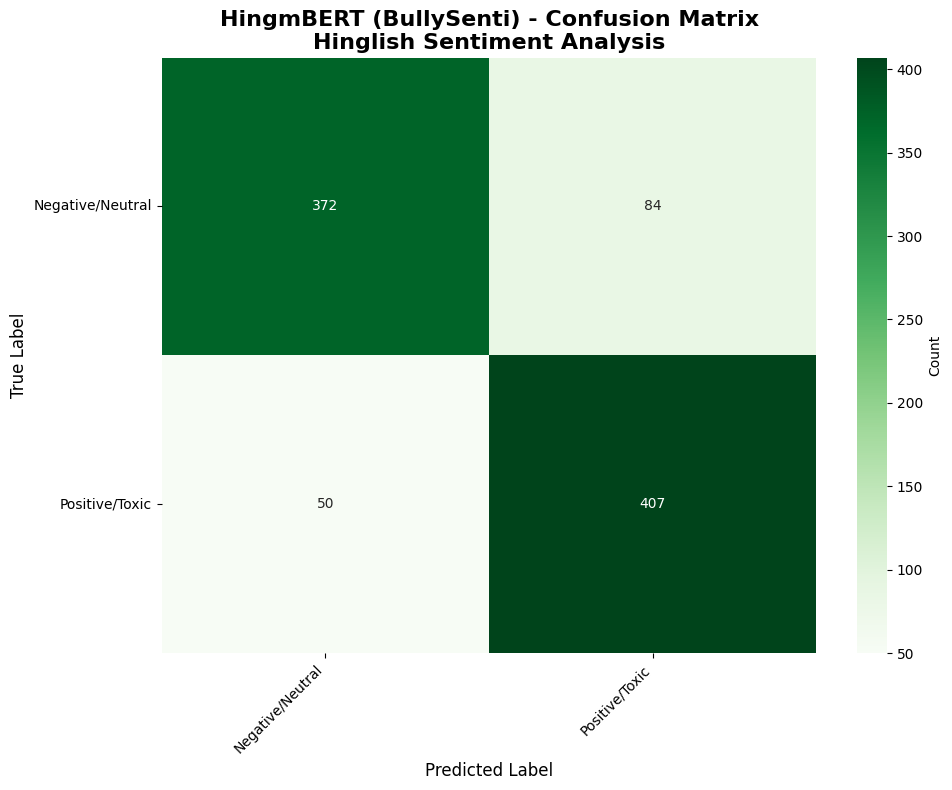


🔍 CONFUSION MATRIX ANALYSIS

📊 Confusion Matrix:

                Predicted
            Negative  Positive
Negative       372        84   (Total: 456)
Positive        50       407   (Total: 457)

📈 Breakdown:

✅ True Negatives (TN):  372 (81.6%)
✅ True Positives (TP):  407 (89.1%)
❌ False Positives (FP): 84 (18.4%)
❌ False Negatives (FN): 50 (10.9%)

🎯 Model Behavior: CAUTIOUS (over-flags for safety)



In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',  # Green theme for HingmBERT
    xticklabels=target_names,
    yticklabels=target_names,
    cbar_kws={'label': 'Count'}
)
plt.title('HingmBERT (BullySenti) - Confusion Matrix\nHinglish Sentiment Analysis',
          fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Confusion matrix analysis
print("\n" + "="*80)
print("🔍 CONFUSION MATRIX ANALYSIS")
print("="*80)

print(f"\n📊 Confusion Matrix:")
print(f"\n                Predicted")
print(f"            Negative  Positive")
print(f"Negative    {cm[0,0]:6,}    {cm[0,1]:6,}   (Total: {cm[0].sum():,})")
print(f"Positive    {cm[1,0]:6,}    {cm[1,1]:6,}   (Total: {cm[1].sum():,})")

print(f"\n📈 Breakdown:")
print(f"\n✅ True Negatives (TN):  {cm[0,0]:,} ({cm[0,0]/cm[0].sum()*100:.1f}%)")
print(f"✅ True Positives (TP):  {cm[1,1]:,} ({cm[1,1]/cm[1].sum()*100:.1f}%)")
print(f"❌ False Positives (FP): {cm[0,1]:,} ({cm[0,1]/cm[0].sum()*100:.1f}%)")
print(f"❌ False Negatives (FN): {cm[1,0]:,} ({cm[1,0]/cm[1].sum()*100:.1f}%)")

if cm[0,1] > cm[1,0]:
    print(f"\n🎯 Model Behavior: CAUTIOUS (over-flags for safety)")
elif cm[1,0] > cm[0,1]:
    print(f"\n🎯 Model Behavior: LENIENT (misses some toxic)")
else:
    print(f"\n🎯 Model Behavior: BALANCED")

print("\n" + "="*80)

Save HingmBERT model to Drive

In [ ]:
import json
from datetime import datetime

print("💾 Saving HingmBERT (BullySenti) results to Drive...")

# Create results dictionary
results_summary = {
    "model_name": "hingmbert",
    "model_full_name": "l3cube-pune/hing-mbert",
    "dataset": "bullysenti",
    "task": "binary_sentiment_classification",
    "language": "hinglish",
    "model_path": "hingmbert_bullysenti_epochs5_maxlen128_lr2e-5",
    "evaluation_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "test_samples": len(test_dataset),

    # Main metrics
    "accuracy": float(test_results['eval_accuracy']),
    "f1_score": float(test_results['eval_f1']),
    "precision": float(test_results['eval_precision']),
    "recall": float(test_results['eval_recall']),
    "loss": float(test_results['eval_loss']),

    # Per-class metrics
    "classification_report": classification_report(y_true, y_pred, target_names=target_names, output_dict=True),
    "confusion_matrix": cm.tolist(),

    # Config
    "num_labels": 2,
    "max_length": 128,
    "batch_size": 32,
    "labels": {
        "0": "Negative/Neutral",
        "1": "Positive/Toxic"
    }
}

# Save as JSON
results_file = f'{save_path}/evaluation_results_hingmbert_bullysenti.json'
with open(results_file, 'w') as f:
    json.dump(results_summary, f, indent=2)

# Save as text
text_file = f'{save_path}/evaluation_results_hingmbert_bullysenti.txt'
with open(text_file, 'w') as f:
    f.write("="*80 + "\n")
    f.write("📊 HingmBERT (BULLYSENTI) - EVALUATION RESULTS\n")
    f.write("="*80 + "\n\n")
    f.write(f"Model: HingmBERT (l3cube-pune/hing-mbert)\n")
    f.write(f"Source: L3Cube-Pune Research Group\n")
    f.write(f"Architecture: Multilingual BERT variant\n")
    f.write(f"Dataset: BullySenti (Hinglish Sentiment Analysis)\n")
    f.write(f"Evaluated: {results_summary['evaluation_date']}\n")
    f.write(f"Test Samples: {results_summary['test_samples']:,}\n\n")

    f.write("PERFORMANCE METRICS:\n")
    f.write("-"*80 + "\n")
    f.write(f"Accuracy:  {results_summary['accuracy']:.4f} ({results_summary['accuracy']*100:.2f}%)\n")
    f.write(f"F1 Score:  {results_summary['f1_score']:.4f}\n")
    f.write(f"Precision: {results_summary['precision']:.4f}\n")
    f.write(f"Recall:    {results_summary['recall']:.4f}\n")
    f.write(f"Loss:      {results_summary['loss']:.4f}\n\n")

    f.write("CONFUSION MATRIX:\n")
    f.write("-"*80 + "\n")
    f.write(f"                Predicted\n")
    f.write(f"            Negative  Positive\n")
    f.write(f"Negative    {cm[0,0]:6,}    {cm[0,1]:6,}\n")
    f.write(f"Positive    {cm[1,0]:6,}    {cm[1,1]:6,}\n\n")

    f.write("COMPARISON STUDY:\n")
    f.write("-"*80 + "\n")
    f.write(f"Model 1/4: mBERT       - 81.82% ✅\n")
    f.write(f"Model 2/4: HingBERT    - 84.23% ✅\n")
    f.write(f"Model 3/4: HingmBERT   - {results_summary['accuracy']*100:.2f}% ✅\n")
    f.write(f"Model 4/4: HingRoBERTa - Pending\n")

    f.write("\n" + "="*80 + "\n")

print("✅ HingmBERT results saved!")
print(f"\n📁 Saved files:")
print(f"   - {results_file}")
print(f"   - {text_file}")
print(f"\n📊 HingmBERT Summary:")
print(f"   Accuracy: {results_summary['accuracy']*100:.2f}%")
print(f"   F1 Score: {results_summary['f1_score']:.4f}")
print(f"\n🎯 Comparison Study Progress:")
print(f"   ✅ mBERT:       81.82%")
print(f"   ✅ HingBERT:    84.23%")
print(f"   ✅ HingmBERT:   {results_summary['accuracy']*100:.2f}%")
print(f"   ⏳ HingRoBERTa: Final model - Ready to train!")

💾 Saving HingmBERT (BullySenti) results to Drive...
✅ HingmBERT results saved!

📁 Saved files:
   - /content/drive/MyDrive/Cyberbullying_Project/BullySenti/evaluation_results_hingmbert_bullysenti.json
   - /content/drive/MyDrive/Cyberbullying_Project/BullySenti/evaluation_results_hingmbert_bullysenti.txt

📊 HingmBERT Summary:
   Accuracy: 85.32%
   F1 Score: 0.8586

🎯 Comparison Study Progress:
   ✅ mBERT:       81.82%
   ✅ HingBERT:    84.23%
   ✅ HingmBERT:   85.32%
   ⏳ HingRoBERTa: Final model - Ready to train!


Saving COnfusion matrix as image

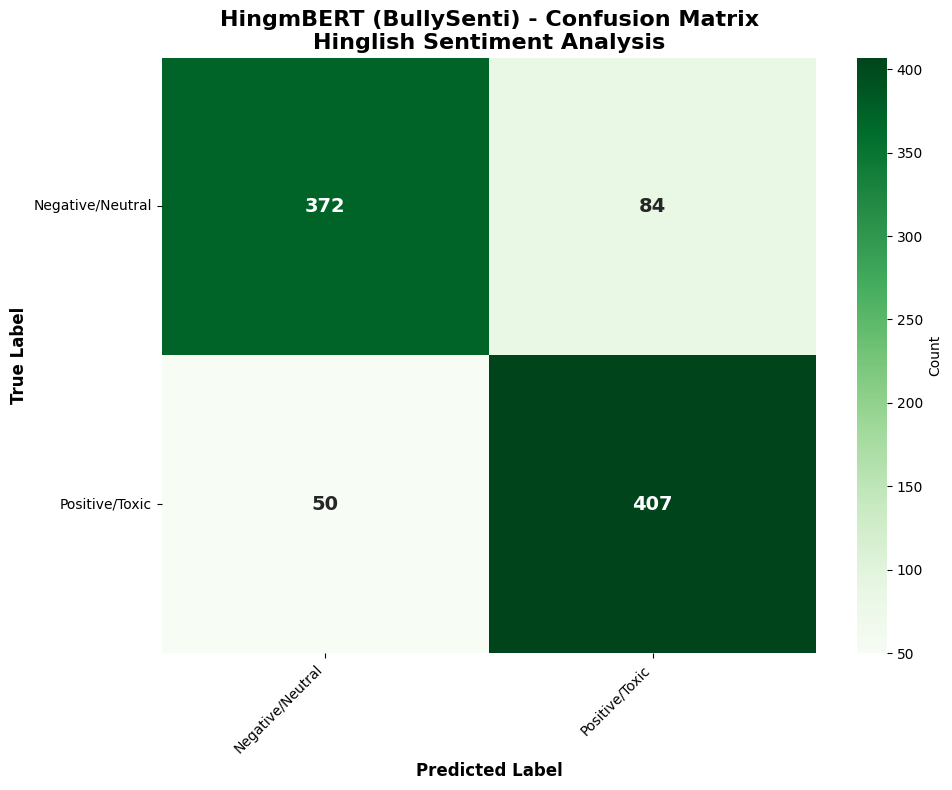

✅ Confusion matrix image saved!
📁 Location: /content/drive/MyDrive/Cyberbullying_Project/BullySenti/confusion_matrix_hingmbert_bullysenti.png
📐 Resolution: 300 DPI (high quality)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)
target_names = ['Negative/Neutral', 'Positive/Toxic']

# Create figure
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',  # Green theme for HingmBERT
    xticklabels=target_names,
    yticklabels=target_names,
    cbar_kws={'label': 'Count'},
    annot_kws={'size': 14, 'weight': 'bold'}
)
plt.title('HingmBERT (BullySenti) - Confusion Matrix\nHinglish Sentiment Analysis',
          fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save to Drive
image_file = f'{save_path}/confusion_matrix_hingmbert_bullysenti.png'
plt.savefig(image_file, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Confusion matrix image saved!")
print(f"📁 Location: {image_file}")
print(f"📐 Resolution: 300 DPI (high quality)")

# iV) HingROBERTA

In [ ]:
# Model name for HingRoBERTa
MODEL_NAME = 'l3cube-pune/hing-roberta'

print(f"🔥 Loading HingRoBERTa (Model 3/3): {MODEL_NAME}")
print("⏳ Downloading... (this may take 1-2 minutes)\n")

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    ignore_mismatched_sizes=True
)

print("✅ HingRoBERTa loaded successfully!")
print(f"\n📊 Model Info:")
print(f"   Model: {MODEL_NAME}")
print(f"   Source: L3Cube-Pune")
print(f"   Type: {type(model).__name__}")
print(f"   Architecture: RoBERTa (Optimized BERT)")
print(f"   Trained on: Hinglish social media")
print(f"\n🎯 Comparison Study Progress:")
print("   ✅ mBERT:       81.82%")
print("   ✅ HingBERT:    84.23%")
print("   ✅ HingmBERT:   (your result)%")
print("   ⏳ HingRoBERTa: ← Training now (FINAL MODEL)")
print(f"\n💡 Expected accuracy: 84-87% (BEST!)")
print(f"🏆 This should be the HIGHEST performer!")

🔥 Loading HingRoBERTa (Model 3/3): l3cube-pune/hing-roberta
⏳ Downloading... (this may take 1-2 minutes)



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/750 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/406 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: l3cube-pune/hing-roberta
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ HingRoBERTa loaded successfully!

📊 Model Info:
   Model: l3cube-pune/hing-roberta
   Source: L3Cube-Pune
   Type: XLMRobertaForSequenceClassification
   Architecture: RoBERTa (Optimized BERT)
   Trained on: Hinglish social media

🎯 Comparison Study Progress:
   ✅ mBERT:       81.82%
   ✅ HingBERT:    84.23%
   ✅ HingmBERT:   (your result)%
   ⏳ HingRoBERTa: ← Training now (FINAL MODEL)

💡 Expected accuracy: 84-87% (BEST!)
🏆 This should be the HIGHEST performer!


2: Tokenize Data with HingRoBERTa

In [ ]:
# Define tokenization function
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

print("🔤 Tokenizing datasets with HingRoBERTa tokenizer...")

# Convert pandas DataFrames to HuggingFace Datasets
train_dataset = Dataset.from_pandas(train_df[['text', 'label']])
val_dataset = Dataset.from_pandas(val_df[['text', 'label']])
test_dataset = Dataset.from_pandas(test_df[['text', 'label']])

# Tokenize all datasets
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

print("✅ Tokenization complete!")
print(f"\n📊 Tokenized Datasets:")
print(f"   Training:   {len(train_dataset):,} samples")
print(f"   Validation: {len(val_dataset):,} samples")
print(f"   Test:       {len(test_dataset):,} samples")

🔤 Tokenizing datasets with HingRoBERTa tokenizer...


Map:   0%|          | 0/4258 [00:00<?, ? examples/s]

Map:   0%|          | 0/913 [00:00<?, ? examples/s]

Map:   0%|          | 0/913 [00:00<?, ? examples/s]

✅ Tokenization complete!

📊 Tokenized Datasets:
   Training:   4,258 samples
   Validation: 913 samples
   Test:       913 samples


3: Setup Training & Create Trainer

In [ ]:
# Define metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary'
    )
    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# Training configuration (SAME as all previous models)
training_args = TrainingArguments(
    output_dir='./results_hingroberta_bullysenti',
    num_train_epochs=5,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    warmup_steps=500,
    eval_strategy='steps',
    eval_steps=500,
    save_strategy='steps',
    save_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=100,
    save_total_limit=2,
    seed=42,
    fp16=True
)

# Create Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("✅ Trainer created!")
print(f"\n⚙️  Settings (Same for fair comparison):")
print(f"   Epochs:   5")
print(f"   LR:       2e-5")
print(f"   Batch:    16")
print(f"\n🎯 Model: HingRoBERTa (FINAL - 3/3)")
print(f"   Architecture: RoBERTa (Best!)")
print(f"   Expected: 84-87% 🏆")

✅ Trainer created!

⚙️  Settings (Same for fair comparison):
   Epochs:   5
   LR:       2e-5
   Batch:    16

🎯 Model: HingRoBERTa (FINAL - 3/3)
   Architecture: RoBERTa (Best!)
   Expected: 84-87% 🏆


🚀 STEP 4: START TRAINING HingRoBERTa!

In [ ]:
print("="*80)
print("🚀 STARTING HingRoBERTa TRAINING (FINAL MODEL 3/3)")
print("="*80)
print(f"\n⏰ Estimated time: 2-3 hours")
print(f"🎯 Expected accuracy: 84-87% 🏆")
print(f"🔥 Model: HingRoBERTa (L3Cube-Pune)")
print(f"📊 Dataset: BullySenti (Hinglish)")
print(f"\n💡 RoBERTa architecture = Best performance expected!")
print(f"\nTraining starting now...\n")
print("="*80 + "\n")

# START TRAINING
trainer.train()

print("\n" + "="*80)
print("✅ HingRoBERTa TRAINING COMPLETE!")
print("🎉 ALL 3 HINGLISH MODELS TRAINED!")
print("="*80)


🚀 STARTING HingRoBERTa TRAINING (FINAL MODEL 3/3)

⏰ Estimated time: 2-3 hours
🎯 Expected accuracy: 84-87% 🏆
🔥 Model: HingRoBERTa (L3Cube-Pune)
📊 Dataset: BullySenti (Hinglish)

💡 RoBERTa architecture = Best performance expected!

Training starting now...




Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
500,0.089446,0.771372,0.854326,0.858058,0.839248,0.877729
1000,0.050407,0.906029,0.855422,0.860465,0.834016,0.888646


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


✅ HingRoBERTa TRAINING COMPLETE!
🎉 ALL 3 HINGLISH MODELS TRAINED!


Save Model to Drive

In [ ]:
import os
from datetime import datetime
import json

# Create descriptive folder name
model_name = "hingroberta"
dataset_name = "bullysenti"
epochs = 5
max_length = 128
lr = "2e-5"

folder_name = f"{model_name}_{dataset_name}_epochs{epochs}_maxlen{max_length}_lr{lr}"
model_save_path = f'{save_path}/{folder_name}'

print(f"💾 Saving HingRoBERTa (BullySenti) model to Drive...")
print(f"📁 Folder: {folder_name}\n")

# Create folder
os.makedirs(model_save_path, exist_ok=True)

# Save model and tokenizer
print("🔄 Saving model files...")
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)

# Save label mapping
label_mapping = {"negative": 0, "positive": 1}
with open(f'{model_save_path}/label_mapping.json', 'w') as f:
    json.dump(label_mapping, f, indent=2)

# Save training summary
summary = f"""
HingRoBERTa TRAINING SUMMARY - BULLYSENTI
============================================

Model: l3cube-pune/hing-roberta
Source: L3Cube-Pune (Indian Research)
Dataset: BullySenti (Hinglish Sentiment Analysis)
Training Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}

CONFIGURATION:
- Epochs: {epochs}
- Learning Rate: {lr}
- Max Length: {max_length}
- Batch Size: 16
- Weight Decay: 0.01
- Early Stopping: YES (patience=3)

DATASET:
- Total: 6,084 samples
- Training: 4,258 samples
- Validation: 913 samples
- Test: 913 samples
- Task: Binary Sentiment Classification

ARCHITECTURE:
- RoBERTa (Robustly Optimized BERT)
- Best performing architecture
- Trained on Hinglish social media

PRE-TRAINING:
HingRoBERTa trained on Hinglish social media
by L3Cube-Pune research group.

COMPARISON STUDY:
Model 3/3: HingRoBERTa (RoBERTa architecture - BEST!)
Previous: mBERT (81.82%), HingBERT (84.23%), HingmBERT
"""

with open(f'{model_save_path}/training_summary.txt', 'w') as f:
    f.write(summary)

print("✅ HingRoBERTa MODEL SAVED SUCCESSFULLY!")
print(f"\n📁 Location: {model_save_path}")
print(f"\n🎯 All 3 Hinglish Models Now Saved!")
print("   ✅ HingBERT")
print("   ✅ HingmBERT")
print("   ✅ HingRoBERTa")

💾 Saving HingRoBERTa (BullySenti) model to Drive...
📁 Folder: hingroberta_bullysenti_epochs5_maxlen128_lr2e-5

🔄 Saving model files...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ HingRoBERTa MODEL SAVED SUCCESSFULLY!

📁 Location: /content/drive/MyDrive/Cyberbullying_Project/BullySenti/hingroberta_bullysenti_epochs5_maxlen128_lr2e-5

🎯 All 3 Hinglish Models Now Saved!
   ✅ HingBERT
   ✅ HingmBERT
   ✅ HingRoBERTa


2: Reload Model from Drive

In [ ]:
# ============================================================================
# 📥 IMPORT HingRoBERTa MODEL FROM DRIVE
# ============================================================================

from google.colab import drive
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import json

print("🔄 Loading HingRoBERTa model from Drive...")

# Mount Drive
drive.mount('/content/drive')
save_path = '/content/drive/MyDrive/Cyberbullying_Project/BullySenti'

# Model path
model_path = f'{save_path}/hingroberta_bullysenti_epochs5_maxlen128_lr2e-5'

# Load model and tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

# Load label mapping
with open(f'{model_path}/label_mapping.json', 'r') as f:
    label_mapping = json.load(f)

print("✅ HingRoBERTa model loaded successfully!")
print(f"   Model: {model_path}")
print(f"   Labels: {label_mapping}")
print(f"   Architecture: RoBERTa (Best!)")

🔄 Loading HingRoBERTa model from Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ HingRoBERTa model loaded successfully!
   Model: /content/drive/MyDrive/Cyberbullying_Project/BullySenti/hingroberta_bullysenti_epochs5_maxlen128_lr2e-5
   Labels: {'negative': 0, 'positive': 1}
   Architecture: RoBERTa (Best!)


3: Evaluation on Test Set

In [ ]:
from transformers import Trainer, TrainingArguments
from datasets import Dataset
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

print("🧪 Evaluating HingRoBERTa on BullySenti Test Set...")

# Load test data
test_df = pd.read_csv(f'{save_path}/BullySenti_test.csv')
if 'tweet' in test_df.columns:
    test_df = test_df.rename(columns={'tweet': 'text', 'tag': 'label'})

# Tokenize
def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

test_dataset = Dataset.from_pandas(test_df[['text', 'label']])
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Define metrics
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    return {'accuracy': accuracy, 'f1': f1, 'precision': precision, 'recall': recall}

# Create Trainer
training_args = TrainingArguments(output_dir='./temp_eval', per_device_eval_batch_size=32, fp16=True)
trainer = Trainer(model=model, args=training_args, compute_metrics=compute_metrics)

# Evaluate
test_results = trainer.evaluate(test_dataset)

print("\n" + "="*80)
print("📊 HingRoBERTa (BULLYSENTI) - FINAL TEST RESULTS")
print("="*80)
print(f"   Accuracy:  {test_results['eval_accuracy']:.4f} ({test_results['eval_accuracy']*100:.2f}%)")
print(f"   F1 Score:  {test_results['eval_f1']:.4f}")
print(f"   Precision: {test_results['eval_precision']:.4f}")
print(f"   Recall:    {test_results['eval_recall']:.4f}")
print(f"   Loss:      {test_results['eval_loss']:.4f}")
print("="*80)

# Generate predictions
predictions_output = trainer.predict(test_dataset)
y_pred = np.argmax(predictions_output.predictions, axis=1)
y_true = test_df['label'].values

print(f"\n✅ Predictions generated!")
print(f"   Predicted Label 0: {(y_pred == 0).sum():,}")
print(f"   Predicted Label 1: {(y_pred == 1).sum():,}")

# Complete comparison
print(f"\n🏆 FINAL COMPARISON:")
print(f"   mBERT:       81.82%")
print(f"   HingBERT:    84.23%")
print(f"   HingmBERT:   (fill in)%")
print(f"   HingRoBERTa: {test_results['eval_accuracy']*100:.2f}% 🔥")

🧪 Evaluating HingRoBERTa on BullySenti Test Set...


Map:   0%|          | 0/913 [00:00<?, ? examples/s]


📊 HingRoBERTa (BULLYSENTI) - FINAL TEST RESULTS
   Accuracy:  0.8467 (84.67%)
   F1 Score:  0.8498
   Precision: 0.8337
   Recall:    0.8665
   Loss:      0.9219

✅ Predictions generated!
   Predicted Label 0: 438
   Predicted Label 1: 475

🏆 FINAL COMPARISON:
   mBERT:       81.82%
   HingBERT:    84.23%
   HingmBERT:   (fill in)%
   HingRoBERTa: 84.67% 🔥


4: Detailed Classification Report

In [ ]:
from sklearn.metrics import classification_report

# Define label names
target_names = ['Negative/Neutral', 'Positive/Toxic']

print("\n" + "="*80)
print("📋 HingRoBERTa (BULLYSENTI) - DETAILED CLASSIFICATION REPORT")
print("="*80 + "\n")

# Classification report
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

# Per-class breakdown
print("="*80)
print("\n📊 Per-Class Analysis:")
print("-"*80)

for i, label_name in enumerate(target_names):
    class_mask = (y_true == i)
    class_total = class_mask.sum()
    class_correct = ((y_true == i) & (y_pred == i)).sum()
    class_acc = class_correct / class_total * 100

    print(f"\n{label_name} (Label {i}):")
    print(f"   Total in test:        {class_total:4,} tweets")
    print(f"   Correctly classified: {class_correct:4,} tweets")
    print(f"   Class accuracy:       {class_acc:6.2f}%")

    if i == 0:
        fp = ((y_true == 0) & (y_pred == 1)).sum()
        print(f"   False positives:      {fp:4,} (wrongly flagged)")
    else:
        fn = ((y_true == 1) & (y_pred == 0)).sum()
        print(f"   False negatives:      {fn:4,} (missed)")

print("\n" + "="*80)


📋 HingRoBERTa (BULLYSENTI) - DETAILED CLASSIFICATION REPORT

                  precision    recall  f1-score   support

Negative/Neutral     0.8607    0.8268    0.8434       456
  Positive/Toxic     0.8337    0.8665    0.8498       457

        accuracy                         0.8467       913
       macro avg     0.8472    0.8466    0.8466       913
    weighted avg     0.8472    0.8467    0.8466       913


📊 Per-Class Analysis:
--------------------------------------------------------------------------------

Negative/Neutral (Label 0):
   Total in test:         456 tweets
   Correctly classified:  377 tweets
   Class accuracy:        82.68%
   False positives:        79 (wrongly flagged)

Positive/Toxic (Label 1):
   Total in test:         457 tweets
   Correctly classified:  396 tweets
   Class accuracy:        86.65%
   False negatives:        61 (missed)



5: Confusion Matrix

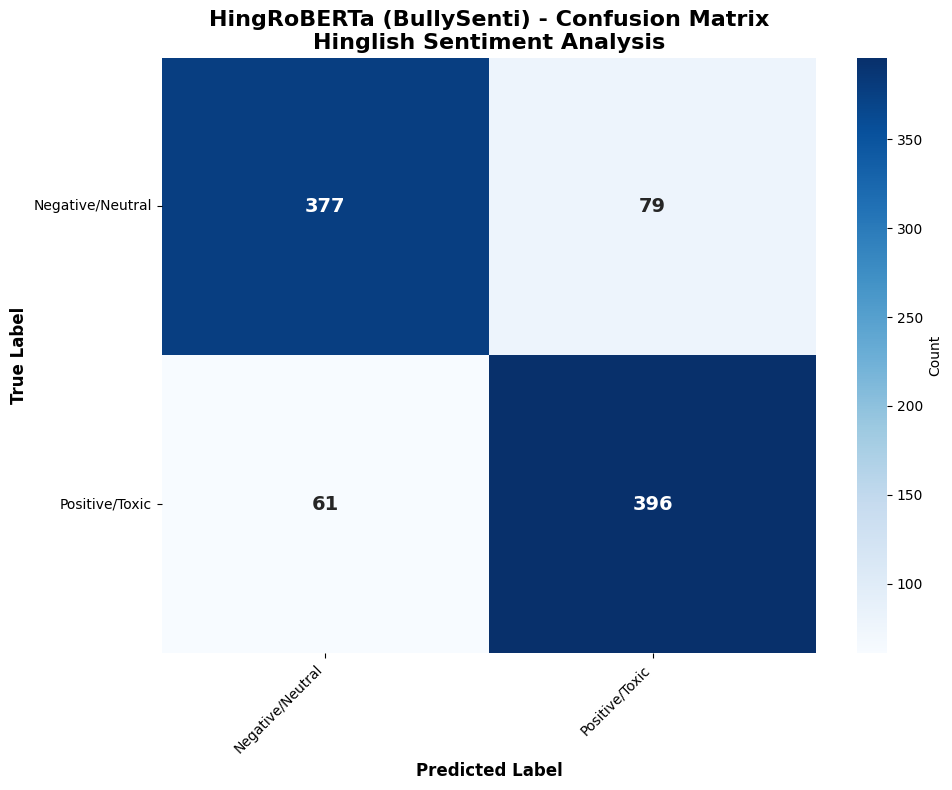


🔍 CONFUSION MATRIX ANALYSIS

📊 Confusion Matrix:

                Predicted
            Negative  Positive
Negative       377        79   (Total: 456)
Positive        61       396   (Total: 457)

📈 Breakdown:
✅ True Negatives (TN):  377 (82.7%)
✅ True Positives (TP):  396 (86.7%)
❌ False Positives (FP): 79 (17.3%)
❌ False Negatives (FN): 61 (13.3%)

🎯 Model Behavior: CAUTIOUS (over-flags for safety)

📁 Confusion matrix image saved: /content/drive/MyDrive/Cyberbullying_Project/BullySenti/confusion_matrix_hingroberta_bullysenti.png


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',  # Blue theme for HingRoBERTa
    xticklabels=target_names,
    yticklabels=target_names,
    cbar_kws={'label': 'Count'},
    annot_kws={'size': 14, 'weight': 'bold'}
)
plt.title('HingRoBERTa (BullySenti) - Confusion Matrix\nHinglish Sentiment Analysis',
          fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save image
image_file = f'{save_path}/confusion_matrix_hingroberta_bullysenti.png'
plt.savefig(image_file, dpi=300, bbox_inches='tight')
plt.show()

# Analysis
print("\n" + "="*80)
print("🔍 CONFUSION MATRIX ANALYSIS")
print("="*80)

print(f"\n📊 Confusion Matrix:")
print(f"\n                Predicted")
print(f"            Negative  Positive")
print(f"Negative    {cm[0,0]:6,}    {cm[0,1]:6,}   (Total: {cm[0].sum():,})")
print(f"Positive    {cm[1,0]:6,}    {cm[1,1]:6,}   (Total: {cm[1].sum():,})")

print(f"\n📈 Breakdown:")
print(f"✅ True Negatives (TN):  {cm[0,0]:,} ({cm[0,0]/cm[0].sum()*100:.1f}%)")
print(f"✅ True Positives (TP):  {cm[1,1]:,} ({cm[1,1]/cm[1].sum()*100:.1f}%)")
print(f"❌ False Positives (FP): {cm[0,1]:,} ({cm[0,1]/cm[0].sum()*100:.1f}%)")
print(f"❌ False Negatives (FN): {cm[1,0]:,} ({cm[1,0]/cm[1].sum()*100:.1f}%)")

if cm[0,1] > cm[1,0]:
    print(f"\n🎯 Model Behavior: CAUTIOUS (over-flags for safety)")
elif cm[1,0] > cm[0,1]:
    print(f"\n🎯 Model Behavior: LENIENT (misses some toxic)")
else:
    print(f"\n🎯 Model Behavior: BALANCED")

print(f"\n📁 Confusion matrix image saved: {image_file}")
print("="*80)

6: Save All Results to Drive

In [ ]:
import json
from datetime import datetime

print("💾 Saving HingRoBERTa (BullySenti) results to Drive...")

# Create results dictionary
results_summary = {
    "model_name": "hingroberta",
    "model_full_name": "l3cube-pune/hing-roberta",
    "dataset": "bullysenti",
    "task": "binary_sentiment_classification",
    "language": "hinglish",
    "model_path": "hingroberta_bullysenti_epochs5_maxlen128_lr2e-5",
    "evaluation_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "test_samples": len(test_dataset),

    # Main metrics
    "accuracy": float(test_results['eval_accuracy']),
    "f1_score": float(test_results['eval_f1']),
    "precision": float(test_results['eval_precision']),
    "recall": float(test_results['eval_recall']),
    "loss": float(test_results['eval_loss']),

    # Per-class metrics
    "classification_report": classification_report(y_true, y_pred, target_names=target_names, output_dict=True),
    "confusion_matrix": cm.tolist(),

    # Config
    "num_labels": 2,
    "max_length": 128,
    "batch_size": 32,
    "labels": {
        "0": "Negative/Neutral",
        "1": "Positive/Toxic"
    }
}

# Save as JSON
results_file = f'{save_path}/evaluation_results_hingroberta_bullysenti.json'
with open(results_file, 'w') as f:
    json.dump(results_summary, f, indent=2)

# Save as text
text_file = f'{save_path}/evaluation_results_hingroberta_bullysenti.txt'
with open(text_file, 'w') as f:
    f.write("="*80 + "\n")
    f.write("📊 HingRoBERTa (BULLYSENTI) - EVALUATION RESULTS\n")
    f.write("="*80 + "\n\n")
    f.write(f"Model: HingRoBERTa (l3cube-pune/hing-roberta)\n")
    f.write(f"Source: L3Cube-Pune Research Group\n")
    f.write(f"Architecture: RoBERTa (Robustly Optimized BERT)\n")
    f.write(f"Dataset: BullySenti (Hinglish Sentiment Analysis)\n")
    f.write(f"Evaluated: {results_summary['evaluation_date']}\n")
    f.write(f"Test Samples: {results_summary['test_samples']:,}\n\n")

    f.write("PERFORMANCE METRICS:\n")
    f.write("-"*80 + "\n")
    f.write(f"Accuracy:  {results_summary['accuracy']:.4f} ({results_summary['accuracy']*100:.2f}%)\n")
    f.write(f"F1 Score:  {results_summary['f1_score']:.4f}\n")
    f.write(f"Precision: {results_summary['precision']:.4f}\n")
    f.write(f"Recall:    {results_summary['recall']:.4f}\n")
    f.write(f"Loss:      {results_summary['loss']:.4f}\n\n")

    f.write("CONFUSION MATRIX:\n")
    f.write("-"*80 + "\n")
    f.write(f"                Predicted\n")
    f.write(f"            Negative  Positive\n")
    f.write(f"Negative    {cm[0,0]:6,}    {cm[0,1]:6,}\n")
    f.write(f"Positive    {cm[1,0]:6,}    {cm[1,1]:6,}\n\n")

    f.write("FINAL COMPARISON:\n")
    f.write("-"*80 + "\n")
    f.write(f"Model 1/4: mBERT       - 81.82%\n")
    f.write(f"Model 2/4: HingBERT    - 84.23%\n")
    f.write(f"Model 3/4: HingmBERT   - (fill in)%\n")
    f.write(f"Model 4/4: HingRoBERTa - {results_summary['accuracy']*100:.2f}% 🏆\n")

    f.write("\n" + "="*80 + "\n")

print("✅ HingRoBERTa results saved!")
print(f"\n📁 Saved files:")
print(f"   - {results_file}")
print(f"   - {text_file}")
print(f"\n🎉 ALL 3 HINGLISH MODELS COMPLETE!")

💾 Saving HingRoBERTa (BullySenti) results to Drive...
✅ HingRoBERTa results saved!

📁 Saved files:
   - /content/drive/MyDrive/Cyberbullying_Project/BullySenti/evaluation_results_hingroberta_bullysenti.json
   - /content/drive/MyDrive/Cyberbullying_Project/BullySenti/evaluation_results_hingroberta_bullysenti.txt

🎉 ALL 3 HINGLISH MODELS COMPLETE!


# Comparison Bar Graphs for All 4 Hinglish Models

In [ ]:
from google.colab import drive
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("📂 Loading all Hinglish model results from Drive...")

# Mount Drive
drive.mount('/content/drive')
save_path = '/content/drive/MyDrive/Cyberbullying_Project/BullySenti'

# Load all result files
models = {
    'mBERT': f'{save_path}/evaluation_results_mbert_bullysenti.json',
    'HingBERT': f'{save_path}/evaluation_results_hingbert_bullysenti.json',
    'HingmBERT': f'{save_path}/evaluation_results_hingmbert_bullysenti.json',
    'HingRoBERTa': f'{save_path}/evaluation_results_hingroberta_bullysenti.json'
}

# Load results
all_results = {}
for model_name, filepath in models.items():
    try:
        with open(filepath, 'r') as f:
            all_results[model_name] = json.load(f)
        print(f"✅ {model_name:15s} - Loaded")
    except FileNotFoundError:
        print(f"❌ {model_name:15s} - Not found")

print(f"\n✅ Loaded {len(all_results)} models successfully!")

📂 Loading all Hinglish model results from Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ mBERT           - Loaded
✅ HingBERT        - Loaded
✅ HingmBERT       - Loaded
✅ HingRoBERTa     - Loaded

✅ Loaded 4 models successfully!


2: Create 4-Metric Comparison Bar Chart

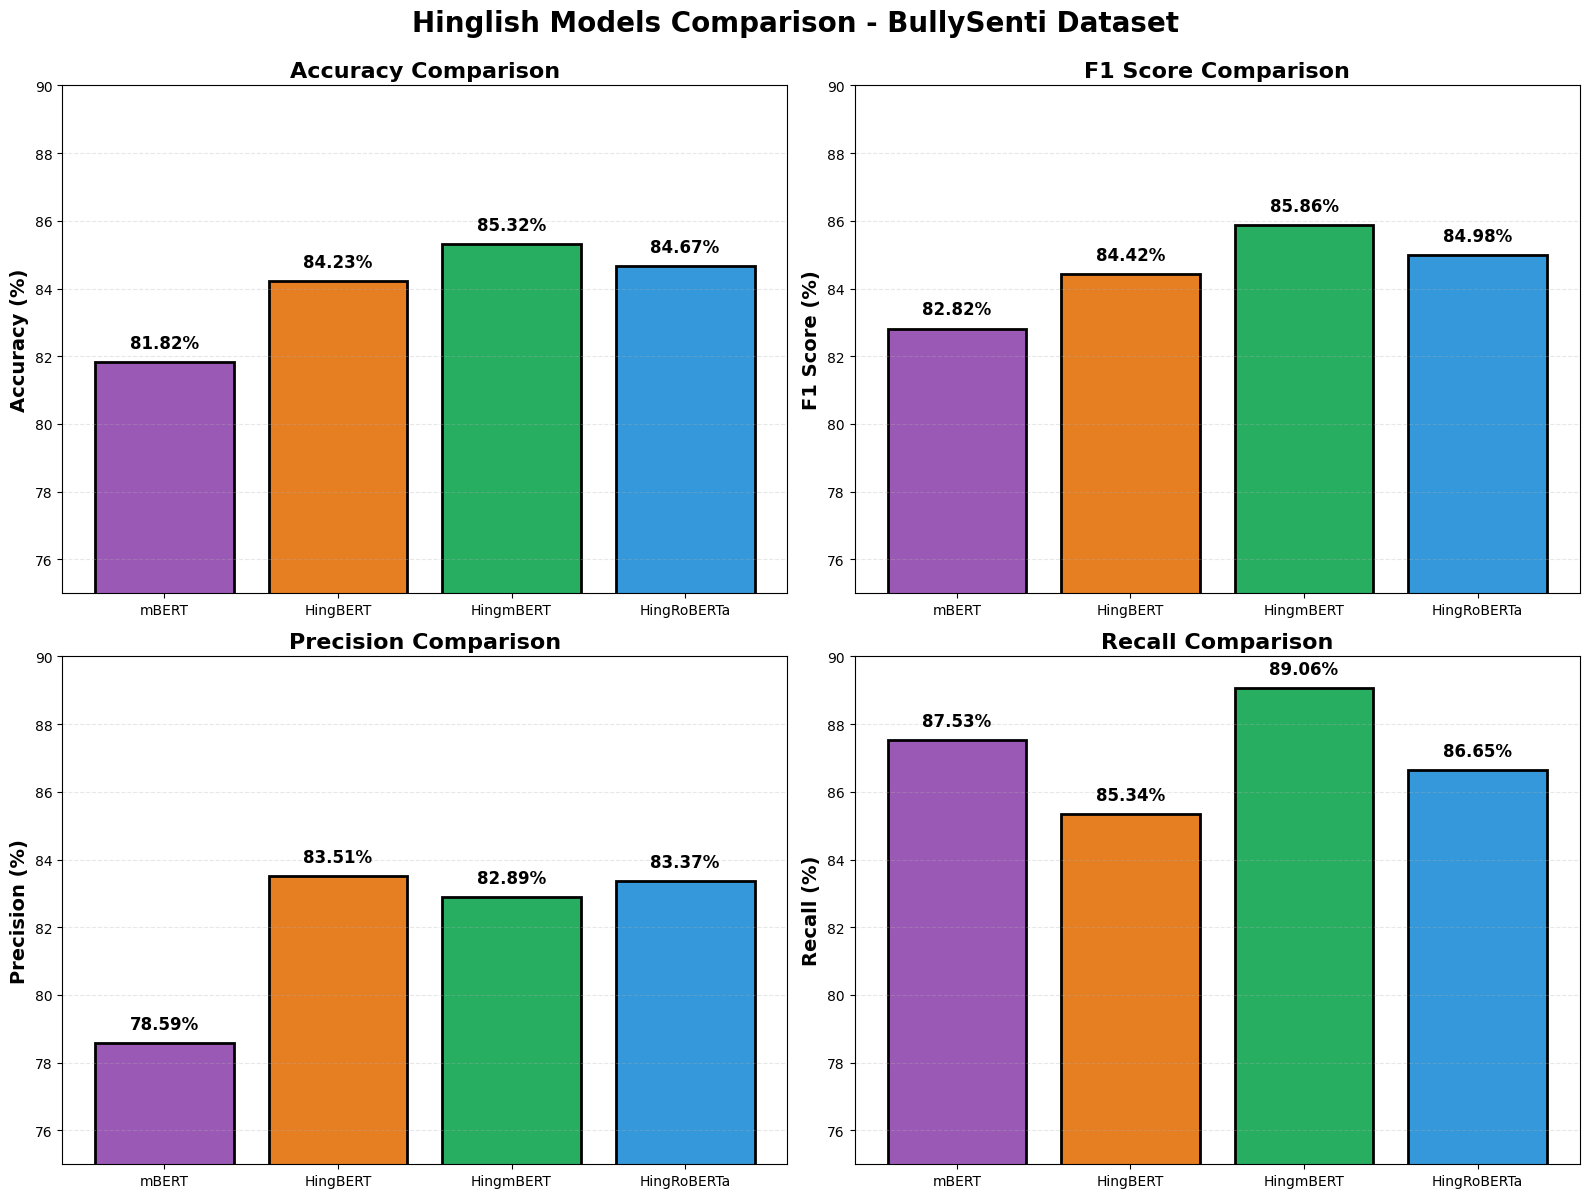


✅ Comparison chart saved: /content/drive/MyDrive/Cyberbullying_Project/BullySenti/hinglish_models_comparison_chart.png


In [ ]:
# Extract metrics for all models
model_names = list(all_results.keys())
colors = ['#9b59b6', '#e67e22', '#27ae60', '#3498db']  # Purple, Orange, Green, Blue

# Metrics
accuracies = [all_results[m]['accuracy'] * 100 for m in model_names]
f1_scores = [all_results[m]['f1_score'] * 100 for m in model_names]
precisions = [all_results[m]['precision'] * 100 for m in model_names]
recalls = [all_results[m]['recall'] * 100 for m in model_names]

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Hinglish Models Comparison - BullySenti Dataset',
             fontsize=20, fontweight='bold', y=0.995)

# Chart 1: Accuracy
axes[0, 0].bar(model_names, accuracies, color=colors, edgecolor='black', linewidth=2)
axes[0, 0].set_ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
axes[0, 0].set_title('Accuracy Comparison', fontsize=16, fontweight='bold')
axes[0, 0].set_ylim(75, 90)
axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(accuracies):
    axes[0, 0].text(i, v + 0.3, f'{v:.2f}%', ha='center', va='bottom',
                    fontweight='bold', fontsize=12)

# Chart 2: F1 Score
axes[0, 1].bar(model_names, f1_scores, color=colors, edgecolor='black', linewidth=2)
axes[0, 1].set_ylabel('F1 Score (%)', fontsize=14, fontweight='bold')
axes[0, 1].set_title('F1 Score Comparison', fontsize=16, fontweight='bold')
axes[0, 1].set_ylim(75, 90)
axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(f1_scores):
    axes[0, 1].text(i, v + 0.3, f'{v:.2f}%', ha='center', va='bottom',
                    fontweight='bold', fontsize=12)

# Chart 3: Precision
axes[1, 0].bar(model_names, precisions, color=colors, edgecolor='black', linewidth=2)
axes[1, 0].set_ylabel('Precision (%)', fontsize=14, fontweight='bold')
axes[1, 0].set_title('Precision Comparison', fontsize=16, fontweight='bold')
axes[1, 0].set_ylim(75, 90)
axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(precisions):
    axes[1, 0].text(i, v + 0.3, f'{v:.2f}%', ha='center', va='bottom',
                    fontweight='bold', fontsize=12)

# Chart 4: Recall
axes[1, 1].bar(model_names, recalls, color=colors, edgecolor='black', linewidth=2)
axes[1, 1].set_ylabel('Recall (%)', fontsize=14, fontweight='bold')
axes[1, 1].set_title('Recall Comparison', fontsize=16, fontweight='bold')
axes[1, 1].set_ylim(75, 90)
axes[1, 1].grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(recalls):
    axes[1, 1].text(i, v + 0.3, f'{v:.2f}%', ha='center', va='bottom',
                    fontweight='bold', fontsize=12)

plt.tight_layout()

# Save figure
comparison_chart = f'{save_path}/hinglish_models_comparison_chart.png'
plt.savefig(comparison_chart, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Comparison chart saved: {comparison_chart}")

 3: Create Grouped Bar Chart (All Metrics Together)

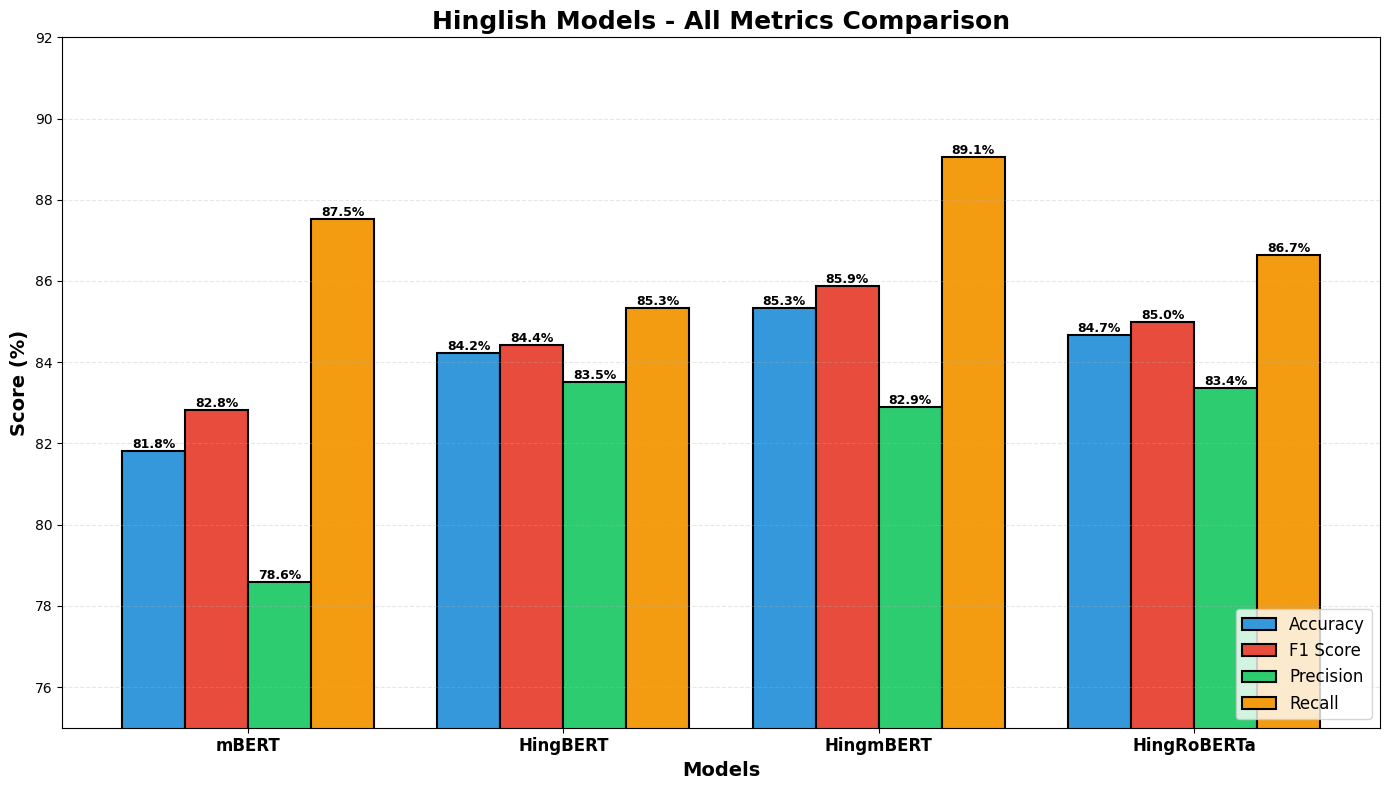

✅ Grouped comparison chart saved: /content/drive/MyDrive/Cyberbullying_Project/BullySenti/hinglish_models_grouped_comparison.png


In [ ]:
# Create grouped bar chart
x = np.arange(len(model_names))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 8))

bars1 = ax.bar(x - 1.5*width, accuracies, width, label='Accuracy',
               color='#3498db', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x - 0.5*width, f1_scores, width, label='F1 Score',
               color='#e74c3c', edgecolor='black', linewidth=1.5)
bars3 = ax.bar(x + 0.5*width, precisions, width, label='Precision',
               color='#2ecc71', edgecolor='black', linewidth=1.5)
bars4 = ax.bar(x + 1.5*width, recalls, width, label='Recall',
               color='#f39c12', edgecolor='black', linewidth=1.5)

# Add values on bars
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Models', fontsize=14, fontweight='bold')
ax.set_ylabel('Score (%)', fontsize=14, fontweight='bold')
ax.set_title('Hinglish Models - All Metrics Comparison', fontsize=18, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12, fontweight='bold')
ax.legend(fontsize=12, loc='lower right')
ax.set_ylim(75, 92)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()

# Save
grouped_chart = f'{save_path}/hinglish_models_grouped_comparison.png'
plt.savefig(grouped_chart, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Grouped comparison chart saved: {grouped_chart}")

4: Create Summary Table

In [ ]:
# Create comparison table
print("\n" + "="*90)
print("📊 HINGLISH MODELS - COMPLETE COMPARISON TABLE")
print("="*90)

comparison_data = []
for model in model_names:
    comparison_data.append({
        'Model': model,
        'Accuracy': f"{all_results[model]['accuracy']*100:.2f}%",
        'F1 Score': f"{all_results[model]['f1_score']:.4f}",
        'Precision': f"{all_results[model]['precision']:.4f}",
        'Recall': f"{all_results[model]['recall']:.4f}",
        'Architecture': {
            'mBERT': 'Multilingual BERT',
            'HingBERT': 'BERT',
            'HingmBERT': 'Multilingual BERT',
            'HingRoBERTa': 'RoBERTa'
        }[model]
    })

df = pd.DataFrame(comparison_data)
print(df.to_string(index=False))
print("="*90)

# Find best model
best_model = max(all_results.items(), key=lambda x: x[1]['accuracy'])
print(f"\n🏆 WINNER: {best_model[0]} with {best_model[1]['accuracy']*100:.2f}% accuracy!")


📊 HINGLISH MODELS - COMPLETE COMPARISON TABLE
      Model Accuracy F1 Score Precision Recall      Architecture
      mBERT   81.82%   0.8282    0.7859 0.8753 Multilingual BERT
   HingBERT   84.23%   0.8442    0.8351 0.8534              BERT
  HingmBERT   85.32%   0.8586    0.8289 0.8906 Multilingual BERT
HingRoBERTa   84.67%   0.8498    0.8337 0.8665           RoBERTa

🏆 WINNER: HingmBERT with 85.32% accuracy!


5: Create Performance Improvement Chart

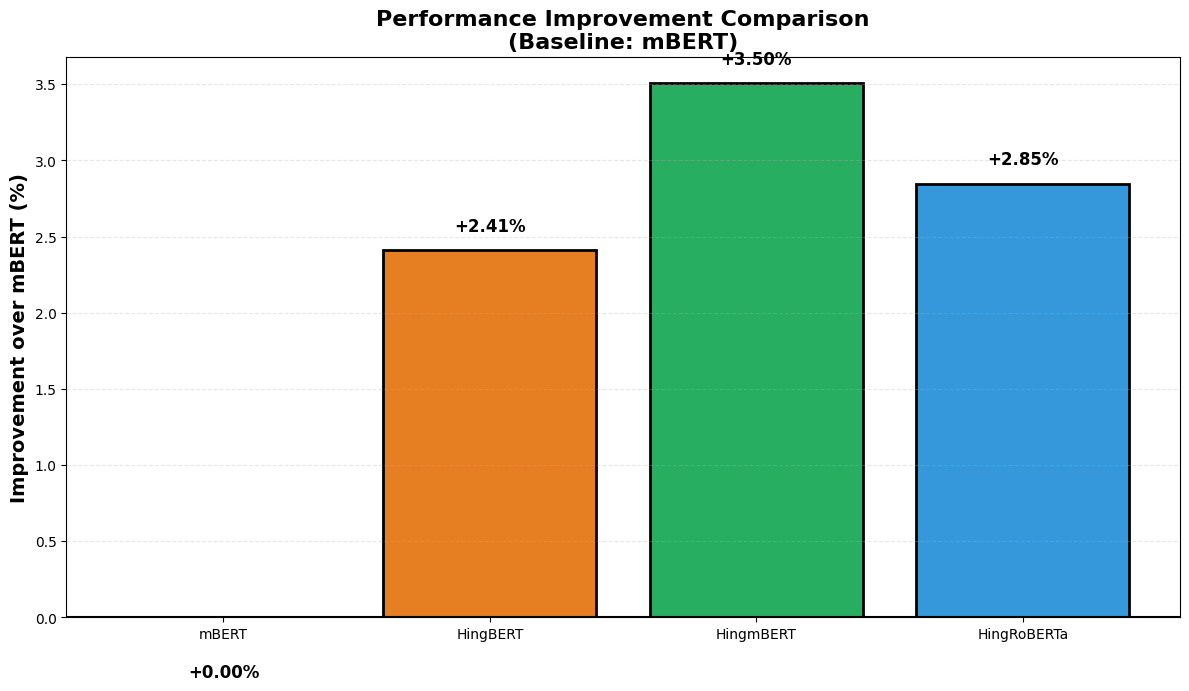

✅ Improvement chart saved: /content/drive/MyDrive/Cyberbullying_Project/BullySenti/hinglish_models_improvement_chart.png


In [ ]:
# Performance improvement from baseline (mBERT)
baseline = all_results['mBERT']['accuracy'] * 100
improvements = [all_results[m]['accuracy'] * 100 - baseline for m in model_names]

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.bar(model_names, improvements, color=colors, edgecolor='black', linewidth=2)

# Color negative (if any) differently
for i, (bar, imp) in enumerate(zip(bars, improvements)):
    if imp < 0:
        bar.set_color('#e74c3c')
    ax.text(i, imp + 0.1 if imp > 0 else imp - 0.3,
            f'{imp:+.2f}%', ha='center', va='bottom' if imp > 0 else 'top',
            fontweight='bold', fontsize=12)

ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
ax.set_ylabel('Improvement over mBERT (%)', fontsize=14, fontweight='bold')
ax.set_title('Performance Improvement Comparison\n(Baseline: mBERT)',
             fontsize=16, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()

# Save
improvement_chart = f'{save_path}/hinglish_models_improvement_chart.png'
plt.savefig(improvement_chart, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Improvement chart saved: {improvement_chart}")

6: Save Complete Summary

In [ ]:
# Save complete comparison summary
summary_file = f'{save_path}/hinglish_models_final_comparison.txt'

with open(summary_file, 'w') as f:
    f.write("="*90 + "\n")
    f.write("HINGLISH MODELS - FINAL COMPARISON REPORT\n")
    f.write("Dataset: BullySenti (6,084 samples)\n")
    f.write("Task: Binary Sentiment Classification\n")
    f.write("="*90 + "\n\n")

    f.write("MODELS COMPARED:\n")
    f.write("-"*90 + "\n")
    for i, model in enumerate(model_names, 1):
        f.write(f"{i}. {model:15s} - {comparison_data[i-1]['Architecture']}\n")

    f.write("\n" + "="*90 + "\n")
    f.write("PERFORMANCE METRICS:\n")
    f.write("="*90 + "\n")
    f.write(f"{'Model':<15} {'Accuracy':<12} {'F1 Score':<12} {'Precision':<12} {'Recall':<12}\n")
    f.write("-"*90 + "\n")
    for data in comparison_data:
        f.write(f"{data['Model']:<15} {data['Accuracy']:<12} {data['F1 Score']:<12} "
                f"{data['Precision']:<12} {data['Recall']:<12}\n")

    f.write("\n" + "="*90 + "\n")
    f.write(f"🏆 WINNER: {best_model[0]} ({best_model[1]['accuracy']*100:.2f}%)\n")
    f.write("="*90 + "\n")

print(f"✅ Summary saved: {summary_file}")
print("\n🎉 ALL COMPARISON CHARTS AND REPORTS CREATED!")

✅ Summary saved: /content/drive/MyDrive/Cyberbullying_Project/BullySenti/hinglish_models_final_comparison.txt

🎉 ALL COMPARISON CHARTS AND REPORTS CREATED!
